In [2]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import gurobipy as gp
from gurobipy import GRB
import time
import math
import itertools
import sys
import seaborn

## Utility function

In [3]:

def volunter_sample(num_samples):

	volunteers_locations = [] 
	# poplist = [ 2910,12330,4007,13390] # benchmark
	# poplist = [12, 5, 18, 14] # total uniform
	poplist = [12, 5, 18, 14]
	
	areas = [
		{'density': poplist[0], 'x_range': (0, 0.5), 'y_range': (0.46, 0.7)},
		{'density': poplist[1], 'x_range': (0, 0.5), 'y_range': (0.36, 0.46)},
		{'density': poplist[2], 'x_range': (0, 0.5), 'y_range': (0, 0.36)},
		{'density': poplist[3], 'x_range': (0.5, 0.7), 'y_range': (0, 0.7)}
	]

	# Calculate the total density
	total_density = sum(area['density'] for area in areas)

	# Define the number of samples (volunteers)

	# Calculate the probability of selecting each area based on its density
	probabilities = [area['density'] / total_density for area in areas]


	# Sample areas based on their density probabilities
	selected_areas = np.random.choice(len(areas), size=num_samples, p=probabilities)
	

	for area_index in selected_areas:
		area = areas[area_index]
		x = np.random.uniform(area['x_range'][0], area['x_range'][1])
		y = np.random.uniform(area['y_range'][0], area['y_range'][1])
		volunteers_locations.append(x)
		volunteers_locations.append(y)
		
	volunteers_locations = np.array(volunteers_locations)
	


	return volunteers_locations

def construct_sample(sample_df, volunteer_number = 1):
	 	
	for i in range(volunteer_number):
		sample_df[f'y{i}1'] = 0
		sample_df[f'y{i}2'] = 0

	for i in range(len(sample_df)):
		
		points_value = volunter_sample(volunteer_number)
		sample_df.iloc[i, 2:] = points_value
	
	return sample_df




def coordinate(i,j,GridNumber):

	edge_length = 0.7
	cell_size = edge_length / GridNumber

	x = cell_size/2+i*cell_size
	y = cell_size/2+j*cell_size
	return x, y

def count_duplicates(row):
	value_counts = row.value_counts()
	return [value for value in value_counts.index]


def build_index_sets(row):
	index_sets = {}
	for index, value in enumerate(row):
		if value not in index_sets:
			index_sets[value] = []
		index_sets[value].append(index)
	return index_sets

def distance_calculation (data_frame):
	distance={}
	for i in range (0, len(data_frame)):
		k_value = list(sorted(data_frame[i].keys()))
		for k in range (len(data_frame[i])):
			distance[(i,k)] = k_value[k] 
	return distance

def Set_obtain (data_frame):
	Set_ties={}
	for i in range (0, len(data_frame)):
		sorted_dict = dict(sorted(data_frame[i].items()))
		index = list(sorted(data_frame[i].keys()))
		for k in range (len(data_frame[i])):            
			Set_ties[(i,k)] = sorted_dict[index[k]]
	return Set_ties




def Bender_solution_trans(bender_solution,GridNumber):

	edge_length = 0.7
	cell_size = edge_length / GridNumber
	result = []
	for k in range(0,len(bender_solution),2):
		result.append(cell_size/2+bender_solution[k]*cell_size)
		result.append(cell_size/2+bender_solution[k+1]*cell_size)
	return np.float32(result)
		


## input sample_df with n volunteers. 
def evaluate_obj(sample_df, solution):
	obj_value = 0
	volunteer_number = int(len(sample_df.columns)/2-1)
	for i in range(len(sample_df)):

		X_1 = sample_df.iloc[i,0]
		X_2 = sample_df.iloc[i,1]

		temp_mins = []
		for index in range(1,volunteer_number+1):
			temp = []
			Y_1 = sample_df.iloc[i,index*2]
			Y_2 = sample_df.iloc[i,index*2+1]
			for j in range(0,len(solution),2):
				P_1 = solution[j]
				P_2 = solution[j+1]
				temp.append(np.abs(X_1-P_1)+np.abs(X_2-P_2)+np.abs(Y_1-P_1)+np.abs(Y_2-P_2)) 

			temp_mins.append(min(temp))

		obj_value += min(temp_mins)
			
	return obj_value/len(sample_df)


def Reward_print_average(data):
	
	x = np.linspace(1, len(data),len(data) )
	# Plot the line plot using Seaborn's lineplot function
	seaborn.lineplot(x=x, y=data)
	plt.xlabel('Iteration')
	plt.ylabel('Objective value in kth iteration')
	return 1




def SPSA_optimization(initial_solution,volunteer_number,gavg,iter_number,step):
	optimal_solution = initial_solution
	lens_solution = len(optimal_solution)
	## Automatic Gain Selection
	alpha = 0.602
	gamma=0.101
	print("Number of  volunteer is ", volunteer_number)
	
	sample_df = pd.read_csv('sampled_10000_filtered.csv') # Iteration Sample
	eval_sample = construct_sample(sample_df, volunteer_number)
	#var_sol = objective_variance(initial_solution,sample_size)
	var_sol = 0
	c = np.float32(max((var_sol /gavg) ** 0.5, .0001))
	A = 0.1*2000/(2*gavg) # 1000 is the expected number of loss evaluations per run? 125 iteration
	
	
	gbar = 0
	for _ in range(10):
		ghat = 0
		for j in range(gavg):
			delta = np.random.randint(0,2,lens_solution) * 2 - 1
			obj_plus = evaluate_obj(eval_sample,optimal_solution+delta*c)
			obj_min = evaluate_obj(eval_sample,optimal_solution-delta*c)
			ghat += (obj_plus - obj_min) / (2.0 * c * delta)
		gbar += np.abs(ghat/gavg)

	meanbar = np.mean(gbar)/10
	a = step*((A+1)**alpha)/meanbar

	# print("A: ",A,"c: ",c,"a: ",a)

	### Start iteration
	#start_time = time.time()
	k = 0
	flag = 1
	obj_track = []
	current_obj = evaluate_obj(eval_sample,optimal_solution)
	print("The initial objective function is", current_obj)
	old_obj = 0
	obj_track.append(current_obj)
	terminal_count = 0 
	unconverge_flag = 0

	while k < iter_number and flag:
		
		#print('========== Iteration ', k, ' ========== ')
		a_k = a/(A+1+k)**alpha
		c_k = c/(k+1)**gamma
		old_obj = current_obj
		g_k = 0
		for _ in range(gavg):
			delta = np.random.randint(0,2,lens_solution) * 2 - 1
			obj_plus = evaluate_obj(eval_sample,optimal_solution+delta*c_k)
			obj_min = evaluate_obj(eval_sample,optimal_solution-delta*c_k)
			g_k += (obj_plus - obj_min) / (2.0 * c_k * delta)

		g_k = g_k/gavg
		#print("the g_k is ", g_k)
		optimal_solution = optimal_solution - a_k * g_k

		if max(optimal_solution) >= 0.7 or min(optimal_solution) <= 0:
			flag = 0
			unconverge_flag = 1


		current_obj = evaluate_obj(eval_sample,optimal_solution)
		#print("Current objective value is: ", current_obj)
		obj_track.append(current_obj)

		
		
		if abs(current_obj-old_obj) <= 1e-6:
			terminal_count += 1
		else:
			
			terminal_count = 0

		if terminal_count == 10:
			flag = 0        

		k += 1
		#print("------ Time Elapsed in the iteration %s seconds ------" % (time.time() - start_time))

 

	if obj_track[-1] >= obj_track[0]:
		unconverge_flag = 1
	
	print("The final objective function is", current_obj)


	return optimal_solution, obj_track, current_obj,k, unconverge_flag

def post_evaluation(eval_solution,volunteer_number):
	
	csv_df = pd.read_csv('sampled_1,000,000_filtered.csv') 
	sample_df = construct_sample(csv_df, volunteer_number)
	temp_result = evaluate_obj(sample_df,eval_solution)
	print("The Eval objective function is", temp_result)
	
	  
	return temp_result


## Volunteer Distribution

[0.24489795918367346, 0.10204081632653061, 0.3673469387755102, 0.2857142857142857]


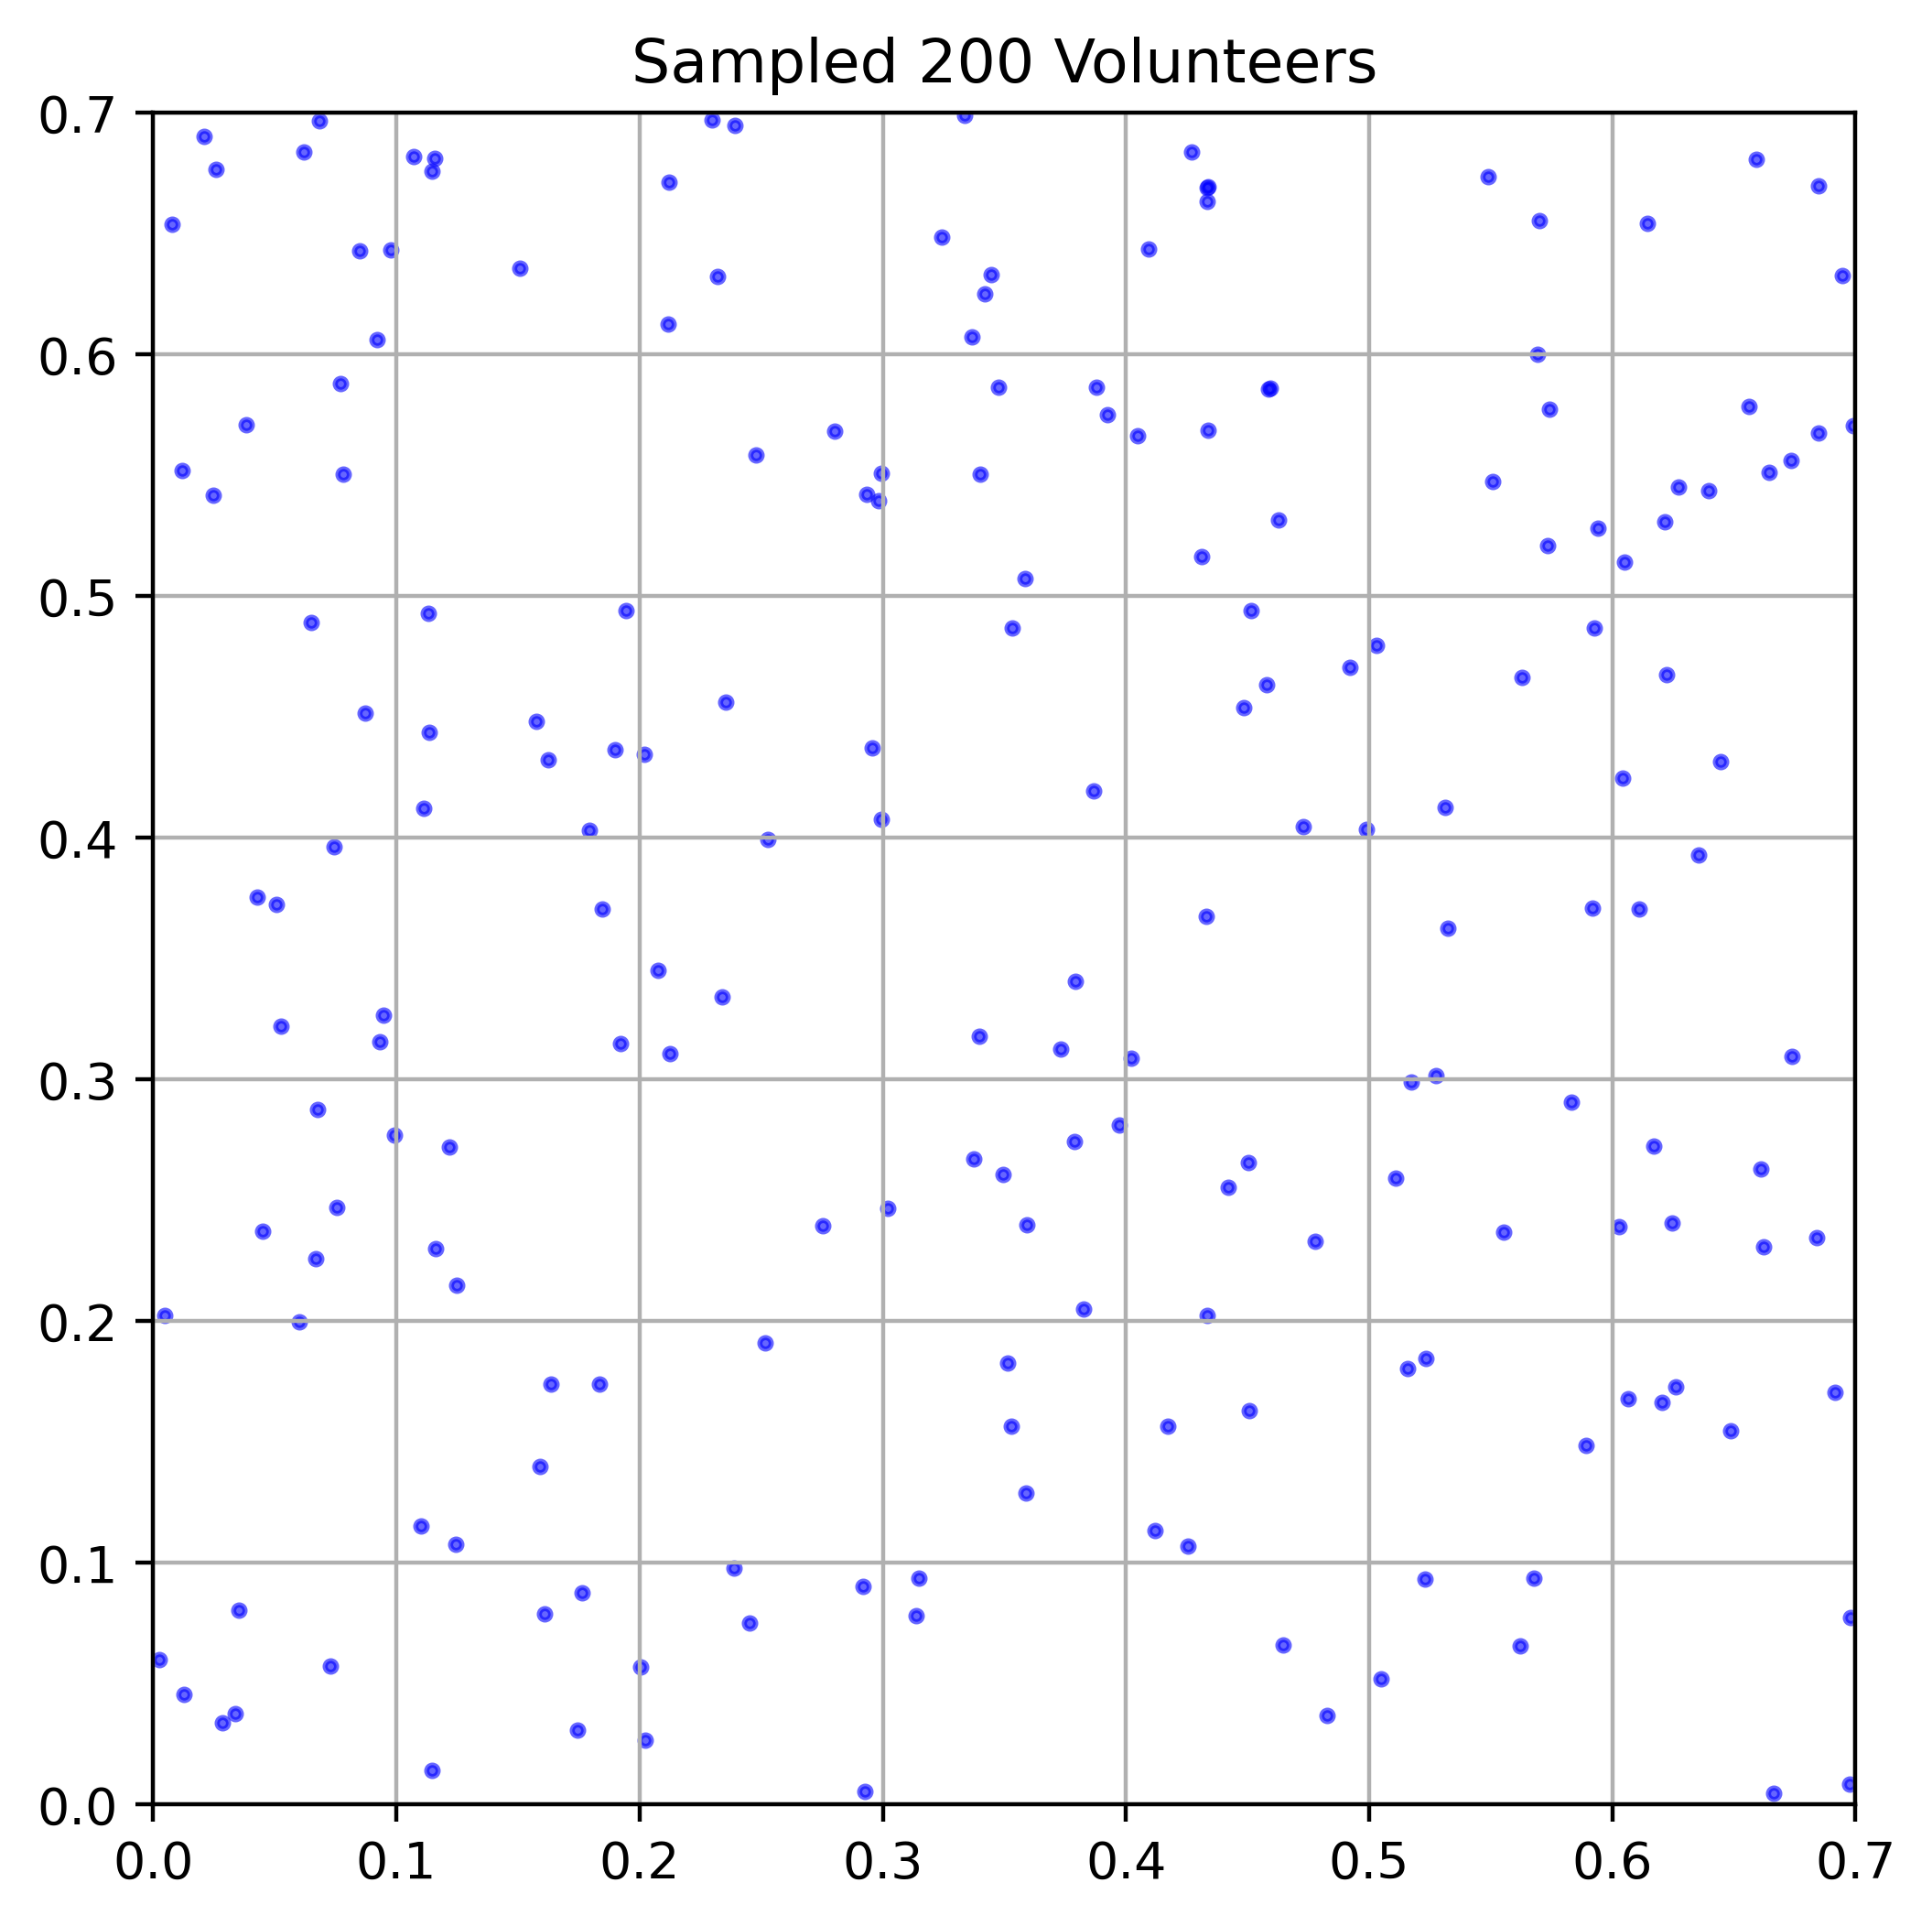

In [224]:
# Define the areas with their densities and coordinate ranges
poplist = [12, 5, 18, 14]
areas = [
	{'density': poplist[0], 'x_range': (0, 0.5), 'y_range': (0.46, 0.7)},
	{'density': poplist[1], 'x_range': (0, 0.5), 'y_range': (0.36, 0.46)},
	{'density': poplist[2], 'x_range': (0, 0.5), 'y_range': (0, 0.36)},
	{'density': poplist[3], 'x_range': (0.5, 0.7), 'y_range': (0, 0.7)}
]

# Calculate the total density
total_density = sum(area['density'] for area in areas)

# Define the number of samples (volunteers)
num_samples = 200

# Calculate the probability of selecting each area based on its density
probabilities = [area['density'] / total_density for area in areas]
print(probabilities)

# Sample areas based on their density probabilities
selected_areas = np.random.choice(len(areas), size=num_samples, p=probabilities)

# Generate the locations of volunteers
volunteers_locations = []

for area_index in selected_areas:
	area = areas[area_index]
	x = np.random.uniform(area['x_range'][0], area['x_range'][1])
	y = np.random.uniform(area['y_range'][0], area['y_range'][1])
	volunteers_locations.append((x, y))

# Convert to numpy array for easy plotting
volunteers_locations = np.array(volunteers_locations)

# Plot the sampled volunteers' locations
plt.figure(figsize=(6, 6))
plt.scatter(volunteers_locations[:, 0], volunteers_locations[:, 1], alpha=0.6, s=5, c='blue')
plt.xlim(0, 0.7)
plt.ylim(0, 0.7)
plt.title('Sampled ' + f'{num_samples}' + ' Volunteers')
plt.grid(True)
plt.show()

## Gurobi Solver

### Warm Start with 3,000 sample

In [8]:

###### Define the warm_start function
def direct_10(Pnumber, volunteer_num=1):
	start_time = time.time()
	hub_grid_number = 20
	sample_df = pd.read_csv('sampled_3,000_filtered.csv') # Iteration Sample
	pair_set = construct_sample(sample_df, volunteer_num)

	print("Number of  volunteer is ", volunteer_num)
	#print("Number of  pair is ", len(pair_set))
	pair_set.head()
	ColumnsName=[f'P{i,j}' for i in range(hub_grid_number) for j in range(hub_grid_number)] # 0..19
	# print(ColumnsName)

	# Rowindex = []

	# for pair in pair_set:
	#     temp = f'O{pair[0],pair[1]}_D{pair[2],pair[3]}'
	#     Rowindex.append(temp)
		
	df = pd.DataFrame( index= range(len(pair_set)), columns=ColumnsName)
	#print("The time of get sample data is ",time.time() - start_time)
	
	
	# Fill in the distance
	for i in range(len(pair_set)):
		Oi = pair_set.iloc[i,0]
		Oj = pair_set.iloc[i,1]
		

		for m in range(hub_grid_number):
			for n in range(hub_grid_number):
				Pi,Pj = coordinate(m,n,hub_grid_number)
				temp = []

				for index in range(1,volunteer_num+1):
					Di = pair_set.iloc[i,index*2]
					Dj = pair_set.iloc[i,index*2+1]
					temp.append(np.abs(Oi-Pi)+np.abs(Oj-Pj)+np.abs(Di-Pi)+np.abs(Dj-Pj))
				
				temp_dis = min(temp)
				df.loc[i,f"P{m,n}"] = round(temp_dis,6)

						
	# Apply the function to each row
	#print("The time of constructing the df data is ", time.time() - start_time)
	result = df.apply(count_duplicates, axis=1)

	#print(result.head())

	NUnique = 0

	for i in range(len(result)):
		NUnique = NUnique + len(result.iloc[i])

	# print("total number of unique arc is", NUnique)
	# TotalArc = len(pair_set)* len(ColumnsName)
	# print("Total number of arc is:", TotalArc)
	# print("the percentage of Arc after reduction", NUnique/TotalArc)



	rows_index_sets = df.apply(build_index_sets, axis=1)

	Kmax = []
	for i in range(len(rows_index_sets)):
		Kmax.append(len(rows_index_sets[i]))

	distance = distance_calculation(rows_index_sets)
	Set_ties = Set_obtain(rows_index_sets)

	m = gp.Model()
	m.Params.MIPGap = 0
	m.params.logtoconsole=0

	# variables: t_ij, y_j, 

	Pair_range = range(len(rows_index_sets))
	Location_range = range(len(ColumnsName))

	t = {}
	for i in Pair_range:
		for k in range(Kmax[i]):
			t[i,k] = m.addVar(vtype=GRB.CONTINUOUS,name = f"t_+{i,k}")

	y = m.addVars(Location_range ,vtype=GRB.BINARY, name="y_i")

	obj = gp.quicksum(

			distance[i,0] + gp.quicksum( (distance[i,k+1]-distance[i,k])*t[i,k] for k in range(Kmax[i]-1))
			for i in Pair_range
		) 
			

	# Constraints

	m.addConstr(gp.quicksum(y[j] for j in Location_range) == Pnumber,name = "plocation")

	for i in Pair_range:
		m.addConstr(t[i,0]+ gp.quicksum(y[j] for j in Set_ties[i,0]) >= 1,name = f"constraint1_{i}")

	for i in Pair_range:
		for k in range(1,Kmax[i]):
			m.addConstr(t[i,k]+ gp.quicksum(y[j] for j in Set_ties[i,k]) >= t[i,k-1],name = f"constraint2_{i}")



	#print("start the optimization")

	m.setObjective(obj, GRB.MINIMIZE)
	m.optimize()
	yvalues = m.getAttr('x',y)

	runtime = m.Runtime
	yvalues = m.getAttr('x',y)
	print("running time is ", runtime)
  
	hubs = []
	for k,y in y.items():
		if y.x > 0:
			hubs.append(k)

	for i in hubs:
		print(ColumnsName[i])
	

	return yvalues


	




In [46]:
P_number = 5

for volunteer_num in [20,25,30,35,40]:
	print("+++++++++++++++ ")
	print("Number of Hub is: ", P_number)
	yvalues_h = direct_10(P_number,volunteer_num)

+++++++++++++++ 
Number of Hub is:  5
Number of  volunteer is  20
Set parameter Username
Academic license - for non-commercial use only - expires 2025-04-02
Set parameter MIPGap to value 0
running time is  152.16558814048767
P(4, 11)
P(12, 11)
P(15, 3)
P(16, 16)
P(17, 10)
+++++++++++++++ 
Number of Hub is:  5
Number of  volunteer is  25
Set parameter MIPGap to value 0
running time is  199.6512689590454
P(4, 11)
P(12, 11)
P(15, 3)
P(16, 16)
P(17, 10)
+++++++++++++++ 
Number of Hub is:  5
Number of  volunteer is  30
Set parameter MIPGap to value 0
running time is  232.27336311340332
P(4, 11)
P(12, 11)
P(15, 3)
P(16, 16)
P(17, 9)
+++++++++++++++ 
Number of Hub is:  5
Number of  volunteer is  35
Set parameter MIPGap to value 0
running time is  352.74399399757385
P(4, 11)
P(12, 11)
P(15, 3)
P(16, 16)
P(17, 10)
+++++++++++++++ 
Number of Hub is:  5
Number of  volunteer is  40
Set parameter MIPGap to value 0
running time is  179.10442996025085
P(4, 11)
P(12, 11)
P(15, 3)
P(16, 16)
P(17, 10)


In [45]:
## evaluate multi volunteer
log_file_path = f"Multi_volunteer_4hubs.txt"
print("Start the calculation of Multi_volunteer")
original_stdout = sys.stdout
P_number = 4
Volunteer_set = [5,10,15,20,25,30,35,40]
with open(log_file_path, 'w') as f:

	sys.stdout = f

	
	print("------------ P_number: ", P_number,"------------")
	for Volunteer in Volunteer_set:
		yvalues_h = direct_10(P_number,Volunteer)
		print("++++++++++++++++++")

	sys.stdout = original_stdout

print("Finish the calculation of Multi_volunteer")

Start the calculation of Multi_volunteer
Finish the calculation of Multi_volunteer


## SPSA 

The hub number is  5.0
[0.1575 0.4025 0.4375 0.4025 0.5425 0.1225 0.5775 0.5775 0.6125 0.3675]
++++++++++++++++++
Number of  volunteer is  40
The initial objective function is 0.18597622055885465
The final objective function is 0.18543925696731295
It is converge
[0.15490008 0.39391132 0.44039495 0.41132995 0.53485774 0.11783929
 0.57567182 0.56905147 0.6161673  0.34429576]
------ Time Elapsed 3850.319299221039 seconds ------


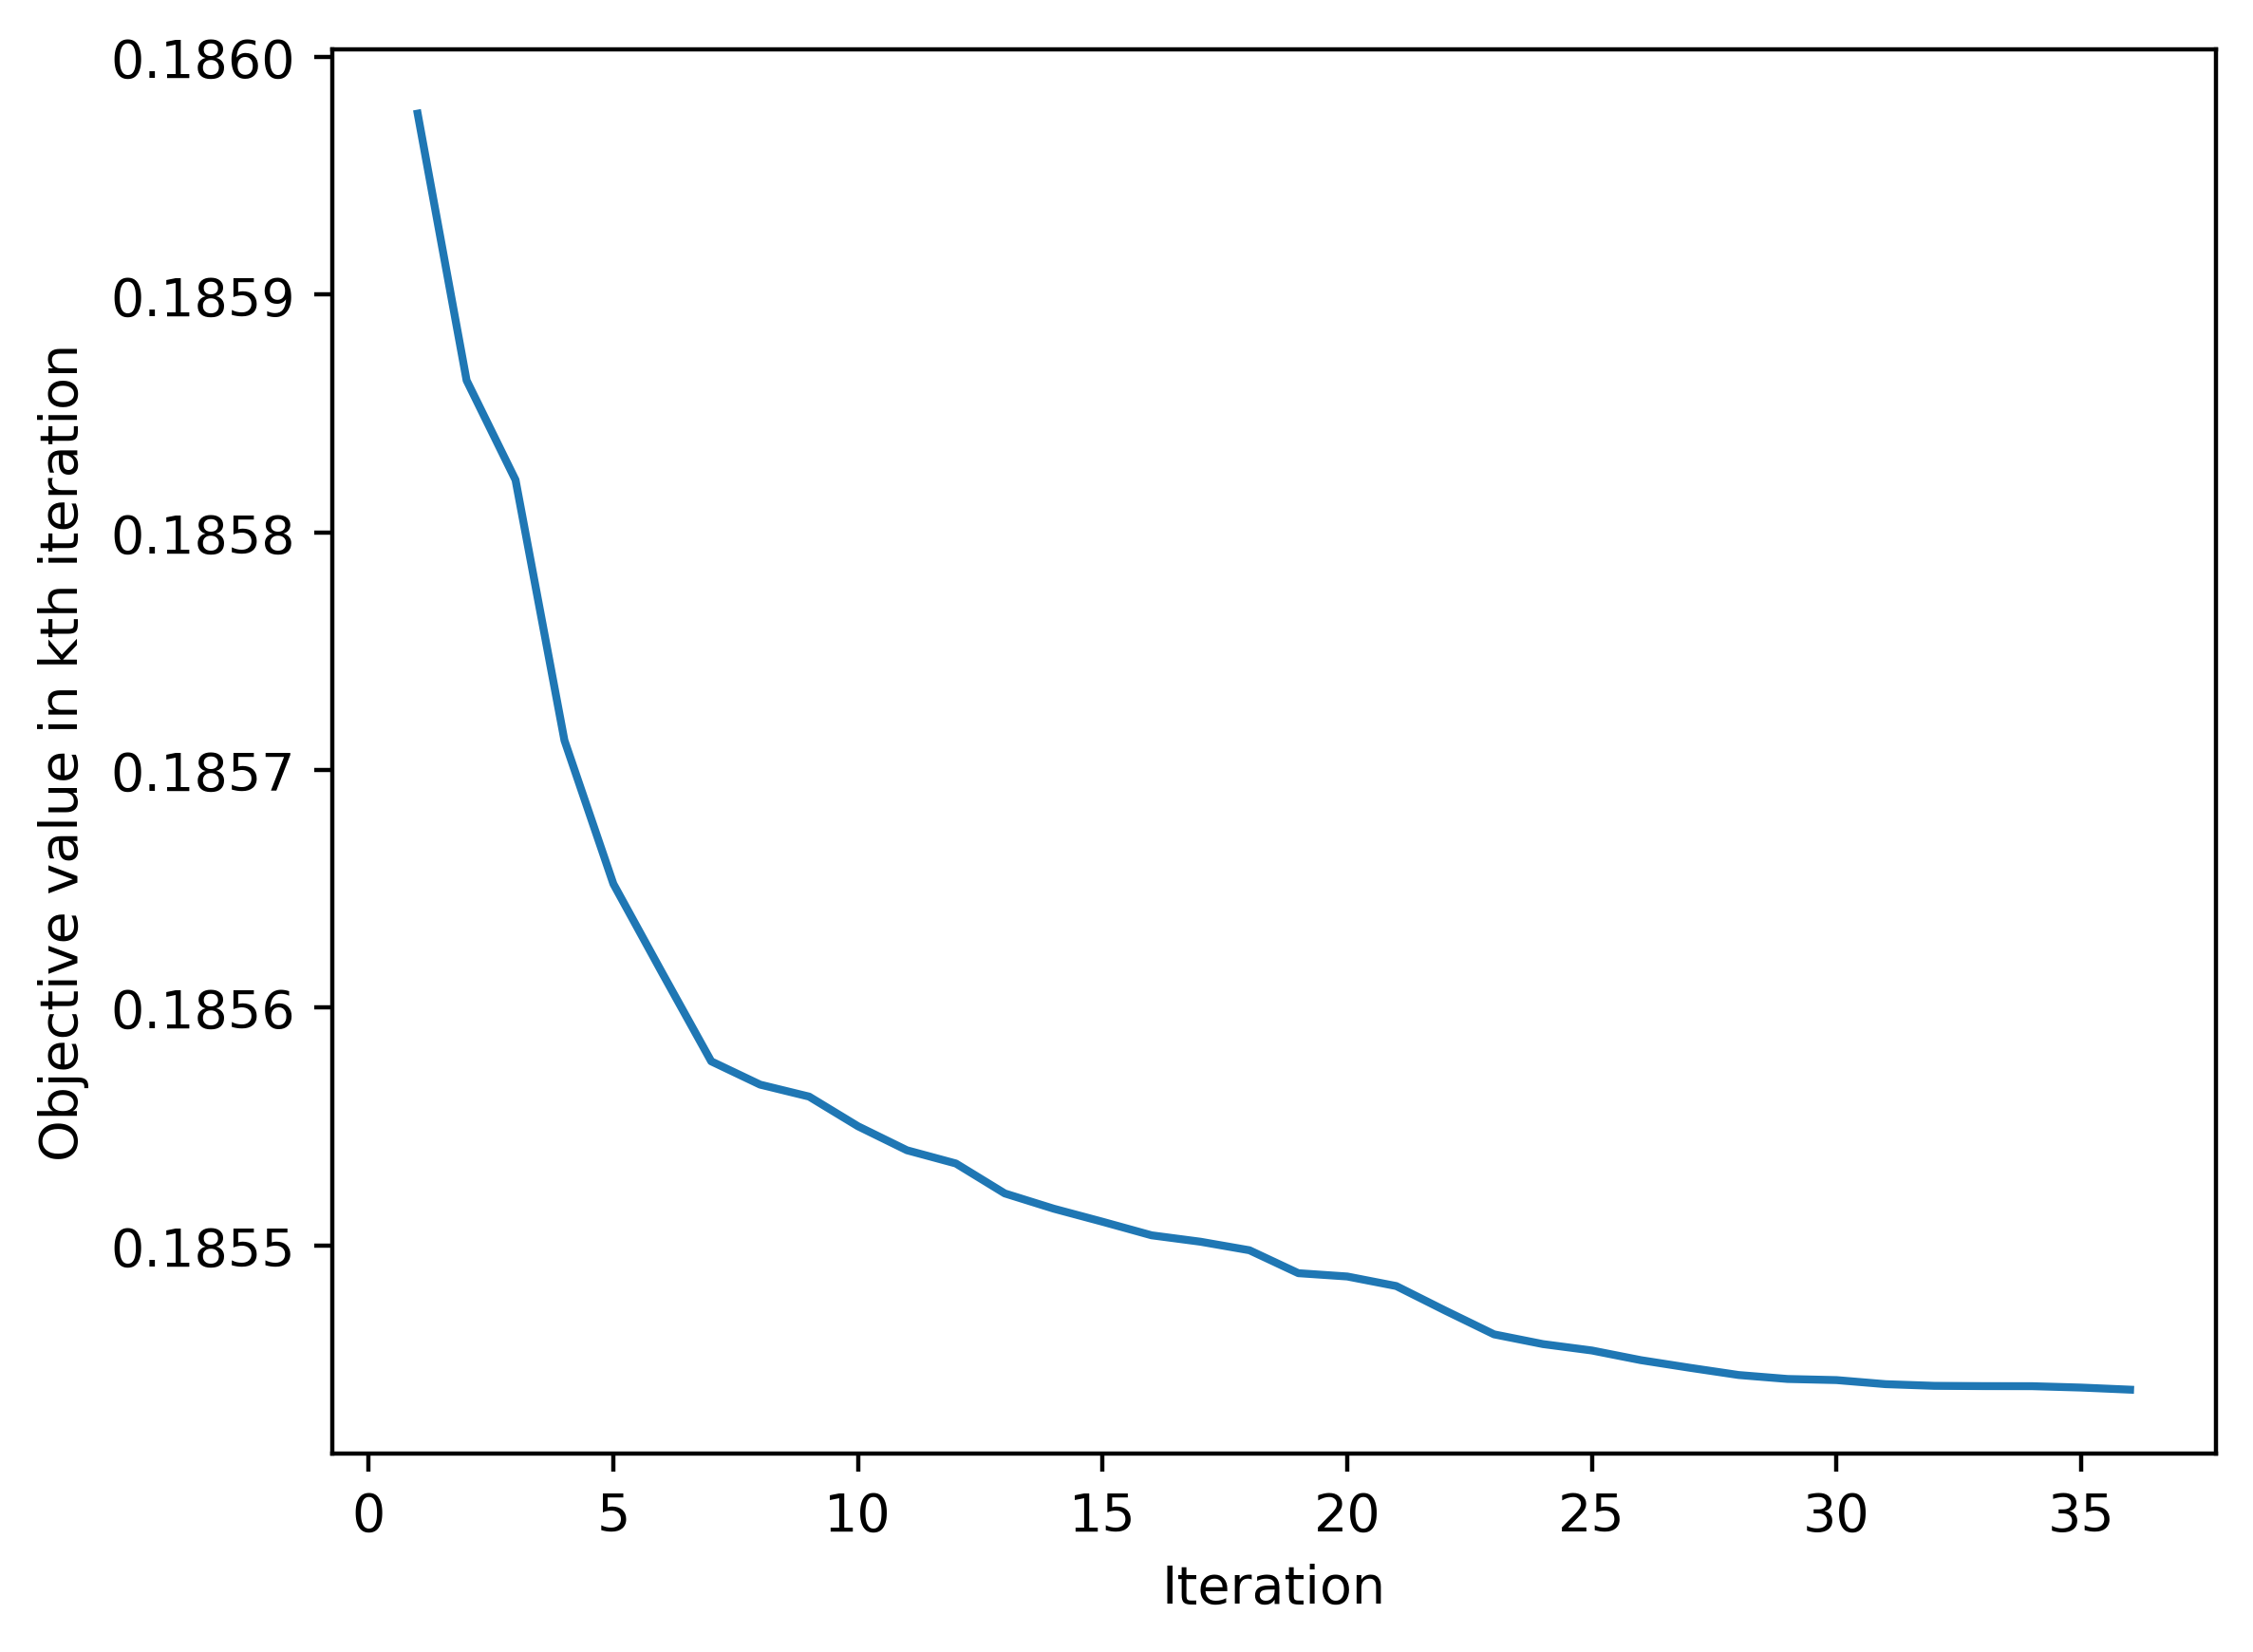

In [50]:
bender_solution =  [4, 11,12, 11,15, 3,16, 16,17, 10]


volunteer_number = 40
step = 0.002 # the initial desired magnitude of change in the theta elements
initial_solution = Bender_solution_trans(bender_solution,20)

print("The hub number is ", len(bender_solution)/2)
print(initial_solution)
print("++++++++++++++++++")
gavg = 4
iter_number = 200

start_time = time.time()
optimal_solution_bender, obj_track,current_obj,iter_SPSA,unconverge_flag = SPSA_optimization(initial_solution,volunteer_number,gavg,iter_number,step)

if unconverge_flag == 1:
	print("It is unconverge")
else:
	print("It is converge")
	
Reward_print_average(obj_track)
print(optimal_solution_bender)
print("------ Time Elapsed %s seconds ------" % (time.time() - start_time))





### Multi-volunteer SPSA

In [ ]:
bender_solutions =   [ [4, 11,12, 11,15, 3,16, 16,17, 10]

,[4, 11,12, 11,15, 3,16, 16,17, 10]

,[4, 11,12, 11,15, 3,16, 16,17, 10]

,[4, 11,12, 11,15, 3,16, 16,17, 10]
]


Volunteer_set = [25,30,35,40]

for i in range(int(len(Volunteer_set))): # range(8)

	bender_solution = bender_solutions[i]
	volunteer_number = round(Volunteer_set[i],6)
	step = 0.005 # the initial desired magnitude of change in the theta elements
	initial_solution = Bender_solution_trans(bender_solution,20)

	print("++++++++++++++++++")
	gavg = 4
	iter_number = 200

	start_time = time.time()
	optimal_solution_bender, obj_track,current_obj,iter_SPSA,unconverge_flag = SPSA_optimization(initial_solution,volunteer_number,gavg,iter_number,step)

	if unconverge_flag == 1:
		print("It is unconverge")
	else:
		print("It is converge")
		
	print(optimal_solution_bender)
	print("------ Time Elapsed %s seconds ------" % (time.time() - start_time))


## Post-Eva

In [16]:

# 8 hubs
eval_solution = [[0.4476705, 0.37027621],  [0.36406901, 0.25387713 ,0.51099351 ,0.47123406], [0.24080004, 0.38509796 ,0.46896363 ,0.20640526 ,0.53936479 ,0.48919787],[0.21107534 ,0.34630123 ,0.42239779 ,0.53625197 ,0.45348252 ,0.17701479,
 0.57940092, 0.39154995], [0.1781298,  0.28956072, 0.33537995, 0.45283258, 0.44938833, 0.16201461,
 0.50705074 ,0.55439746 ,0.57980625, 0.34674611], [0.16963328 ,0.28920308, 0.26989803 ,0.56085209 ,0.40754906, 0.39427778,
 0.45031056, 0.13610389, 0.54535868, 0.51627435, 0.5988278 , 0.29636936],  [0.14316444 ,0.29095247, 0.25956427, 0.51312726 ,0.36299853 ,0.12883332,
 0.42546999, 0.37255699 ,0.5033976 , 0.58139451, 0.54857473, 0.23368937,
 0.60405036 ,0.43551504], [0.13034445, 0.24558399, 0.21444646, 0.48195748, 0.35007329, 0.31743117,
 0.43128526, 0.11960065, 0.41582468, 0.58715927, 0.50733438 ,0.39265878, 0.59252314, 0.22998503, 0.59935805, 0.51850296],[0.11293196 ,0.22505199 ,0.20242206 ,0.48436488 ,0.33345875 ,0.30799728, 0.39968828 , 0.10045056 ,0.40683388 ,0.5932691 , 0.47890572,0.41282379,
 0.54247462 ,0.18858345 ,0.5798558  ,0.52762375 ,0.61836975,0.33000275] ] 

volunter_set = [1]
for index in range(9):
	volunteer_number = volunter_set[0]
	solution = eval_solution[index]
	print("The hubs number is ", len(solution)/2)
	print("The volunteer number is: ", volunteer_number)
	post_evaluation(solution,volunteer_number)

The hubs number is  1.0
The volunteer number is:  1
The Eval objective function is 0.6496253778053488
The hubs number is  2.0
The volunteer number is:  1
The Eval objective function is 0.5763765236950846
The hubs number is  3.0
The volunteer number is:  1
The Eval objective function is 0.5355995267345713
The hubs number is  4.0
The volunteer number is:  1
The Eval objective function is 0.5151253581325937
The hubs number is  5.0
The volunteer number is:  1
The Eval objective function is 0.503618331912097
The hubs number is  6.0
The volunteer number is:  1
The Eval objective function is 0.4944773624406067
The hubs number is  7.0
The volunteer number is:  1
The Eval objective function is 0.48824408694752314
The hubs number is  8.0
The volunteer number is:  1
The Eval objective function is 0.4841763037968024
The hubs number is  9.0
The volunteer number is:  1
The Eval objective function is 0.480195666583278


## Plot


### Volunteer Plot

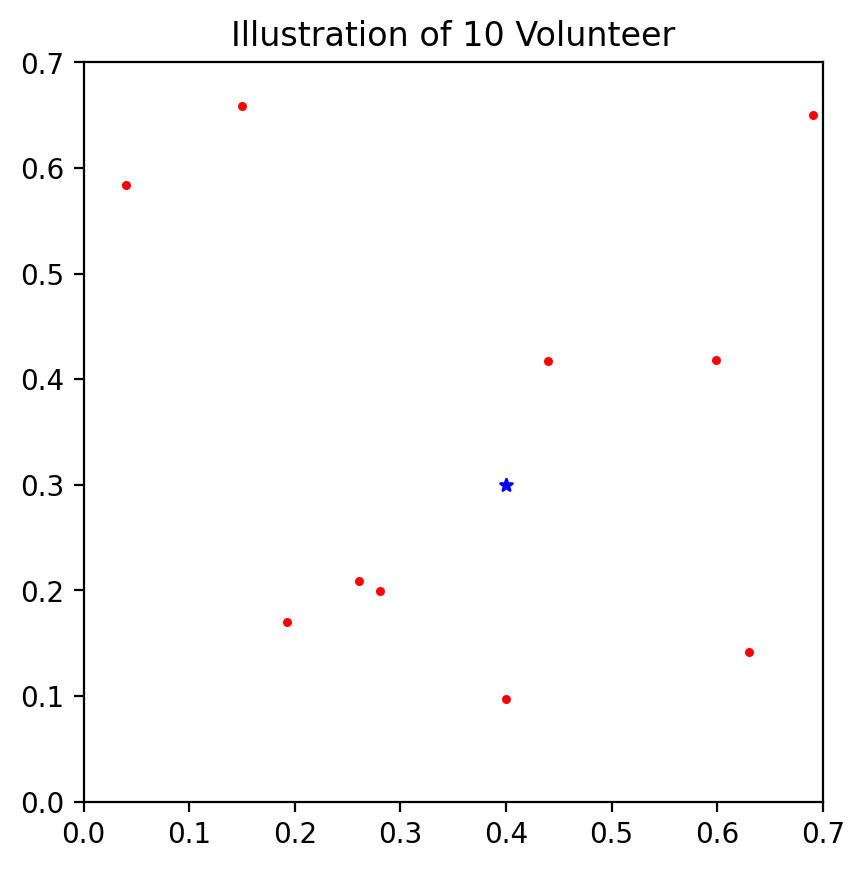

In [65]:
# Define the edge length of the square and the number of divisions
volunteer_number = 10
edge_length = 0.7
plt.rcParams['figure.dpi'] = 200 # 400
# Create the plot
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')


points = np.random.rand(volunteer_number, 2) * 0.7

ax.scatter(points[:, 0], points[:, 1], color='red', s = 5, label='Centers')

ax.scatter(0.4, 0.3, color='b', s = 20, label='Centers',marker='*')
# Set plot limits
ax.set_xlim(0, edge_length)
ax.set_ylim(0, edge_length)

# Add labels and title
ax.set_title('Illustration of ' + f'{volunteer_number}' + ' Volunteer')
# ax.set_xlabel('X')
# ax.set_ylabel('Y')

# Show plot
plt.show()

### Locations

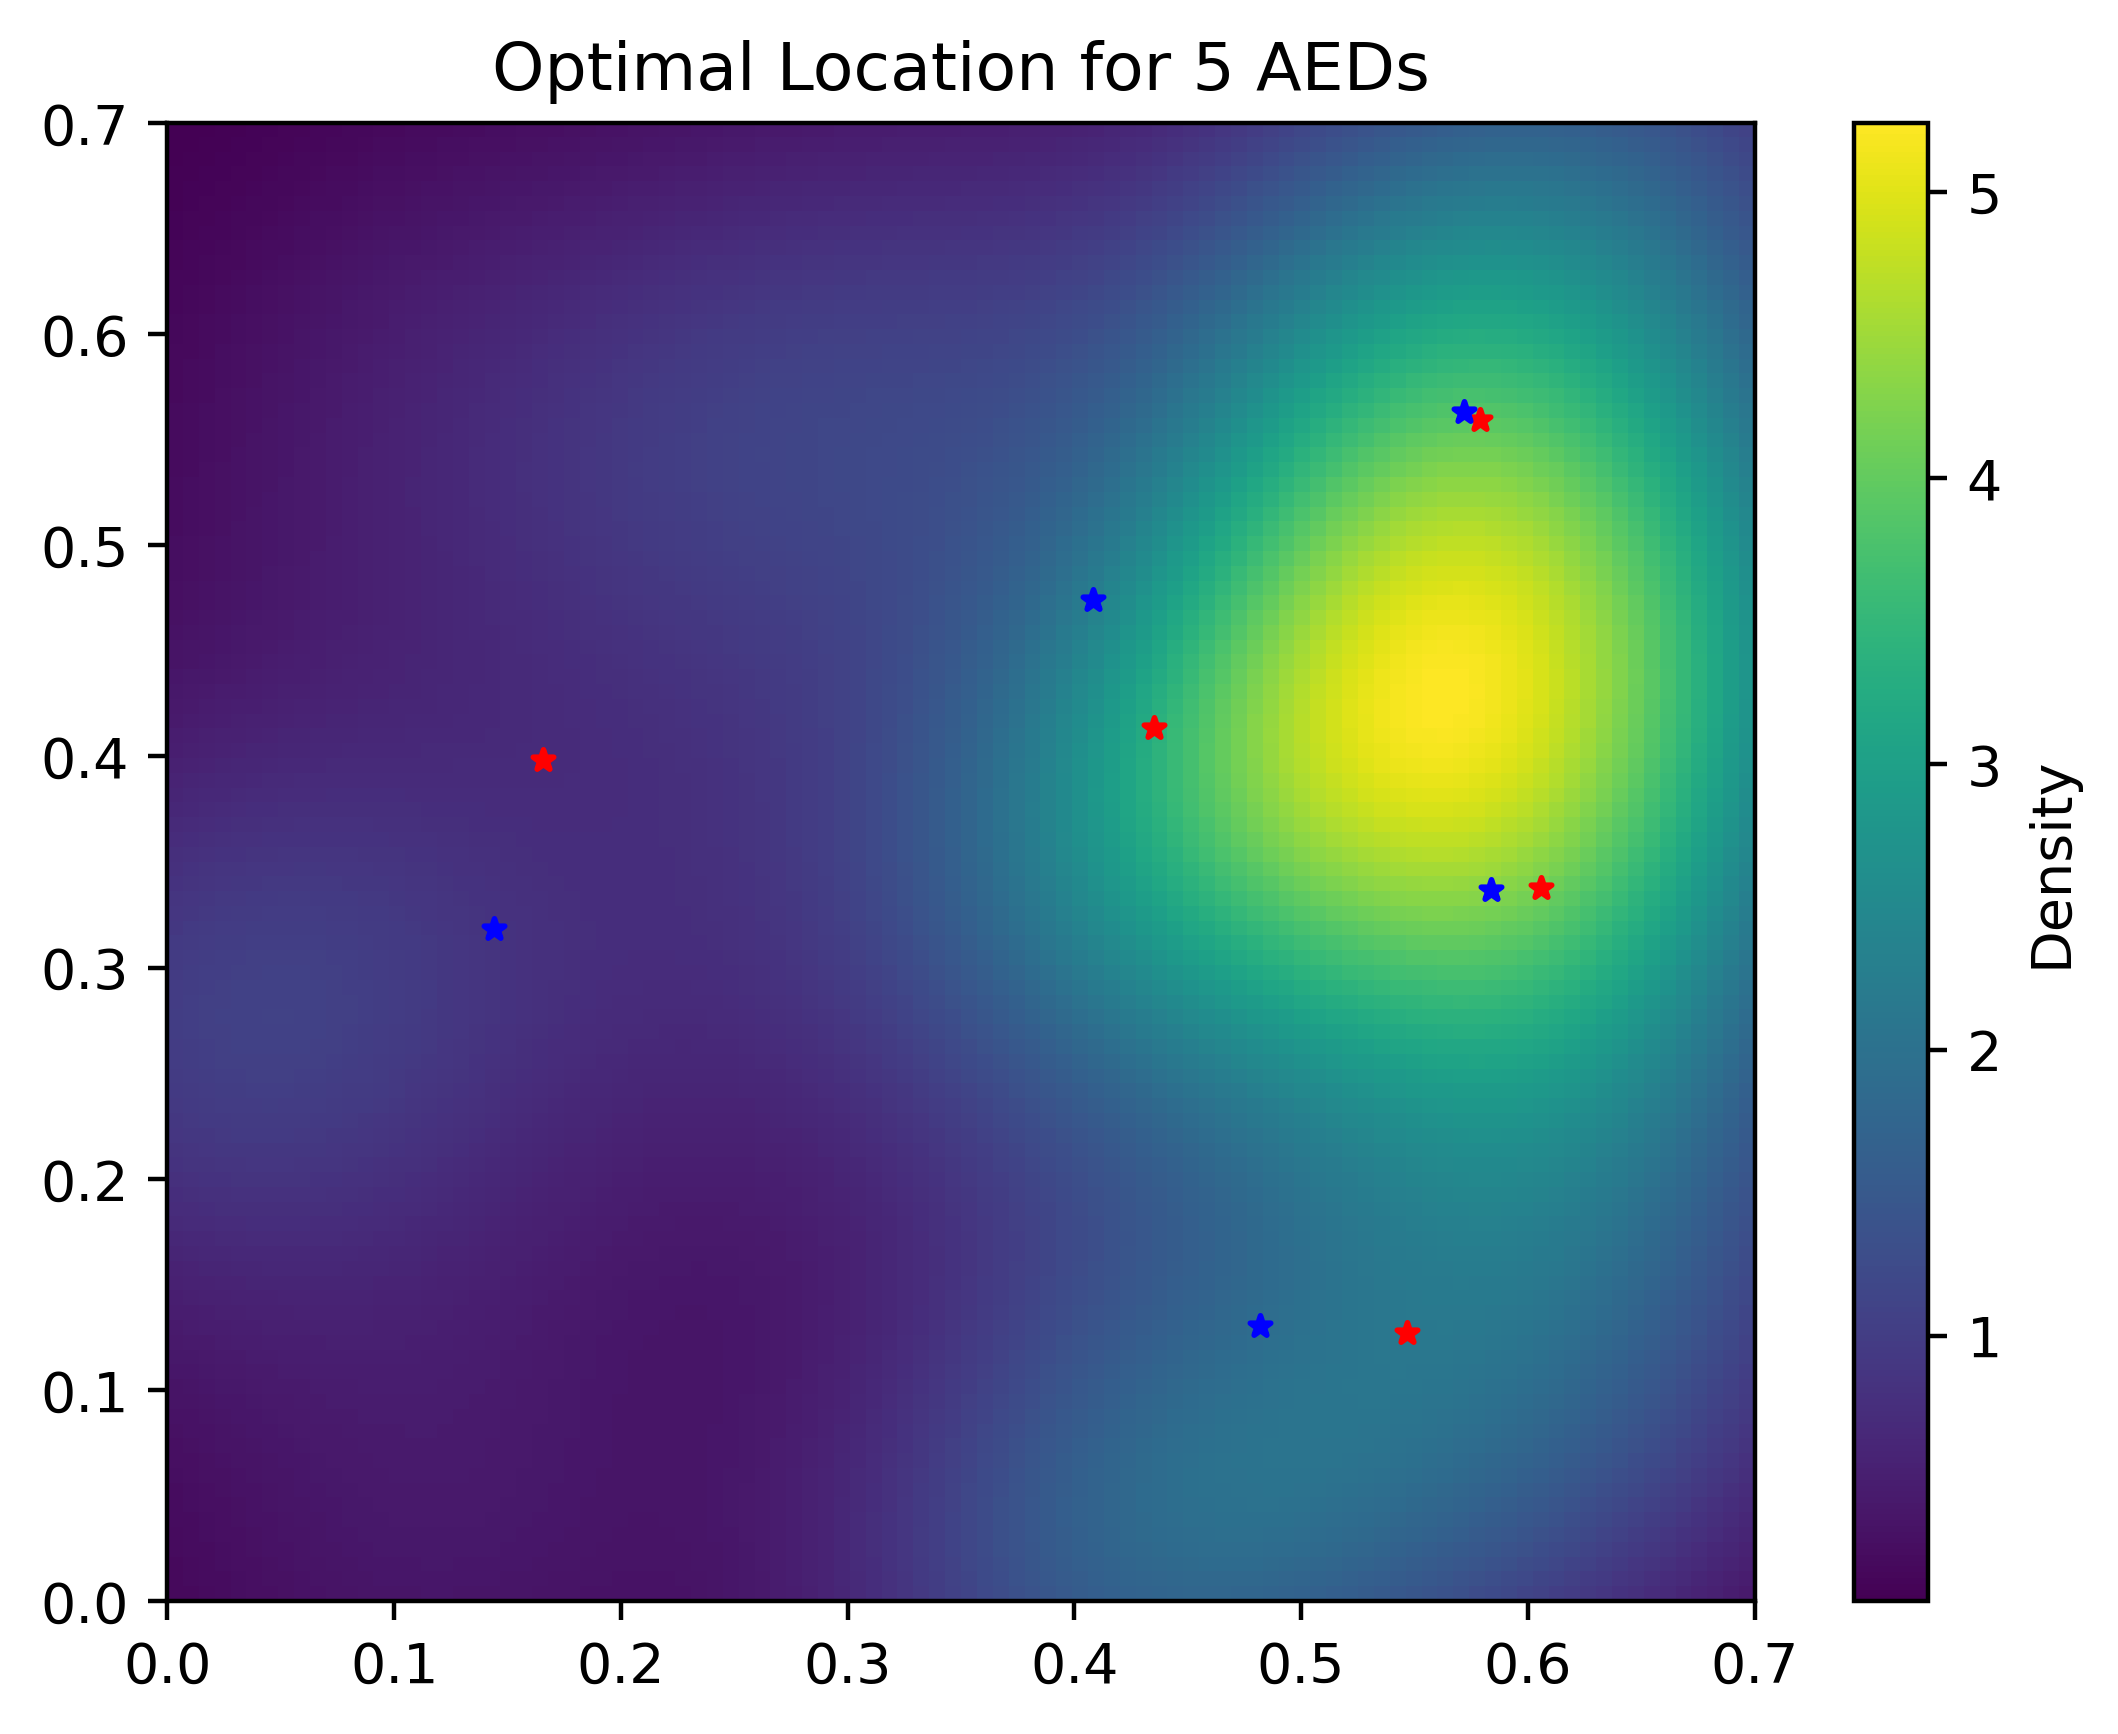

In [237]:
df = pd.read_csv('relative_coordinates.csv')
column1 = df['Rotated_Longitude_miles'].values
column2 = df['Rotated_Latitude_miles'].values
data = np.column_stack((column1, column2))
# Perform KDE
kde = gaussian_kde(data.T)

# Define the grid
x_grid = np.linspace(0, 0.7, 100)
y_grid = np.linspace(0, 0.7, 100)
x, y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([x.ravel(), y.ravel()])

# Evaluate KDE on the grid
pdf = kde(grid_coords).reshape(100, 100)

# Plot the KDE
plt.rcParams['figure.dpi'] = 400
plt.imshow(pdf, origin='lower', extent=(0, 0.7, 0, 0.7), aspect='auto', cmap='viridis')
plt.colorbar(label='Density')



# coor = [ 11, 2,16, 4,3, 6,11, 9, 17, 9,15, 12,5, 14,12, 16,17, 16]

# for i in range(int(len(coor)/2)):
#     x,y = coordinate(coor[i*2], coor[i*2+1],20)
#     plt.scatter(x,y, color='b', s = 10 )

temp =[0.16569062, 0.39814528 ,0.43492666 ,0.4134408 , 0.5465748,  0.12693656,0.5789898  ,0.55944317, 0.60589216 ,0.33748879]

# temp =[0.1781298,  0.28956072, 0.33537995, 0.45283258, 0.44938833, 0.16201461,
#  0.50705074 ,0.55439746 ,0.57980625, 0.34674611]


num = int(len(temp)/2)
for i in range(int(len(temp)/2)):
	x = temp[i*2]
	y = temp[i*2+1]
	plt.scatter(x,y, color='red', s = 15,marker='*')

temp =   [0.14424302,0.31827312 ,0.40803696 ,0.47383209 ,0.48178034 ,0.13042904,
 0.58368995, 0.33663596 ,0.5718048 , 0.56301748]
num = int(len(temp)/2)
for i in range(int(len(temp)/2)):
	x = temp[i*2]
	y = temp[i*2+1]
	plt.scatter(x,y, color='blue', s = 15,marker='*')



# x,y = coordinate(5, 10,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(14, 5,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(15, 14,20)
# plt.scatter(x,y, color='b', s = 10 )



plt.title('Optimal Location for ' + f'{num}' + ' AEDs')
plt.show()






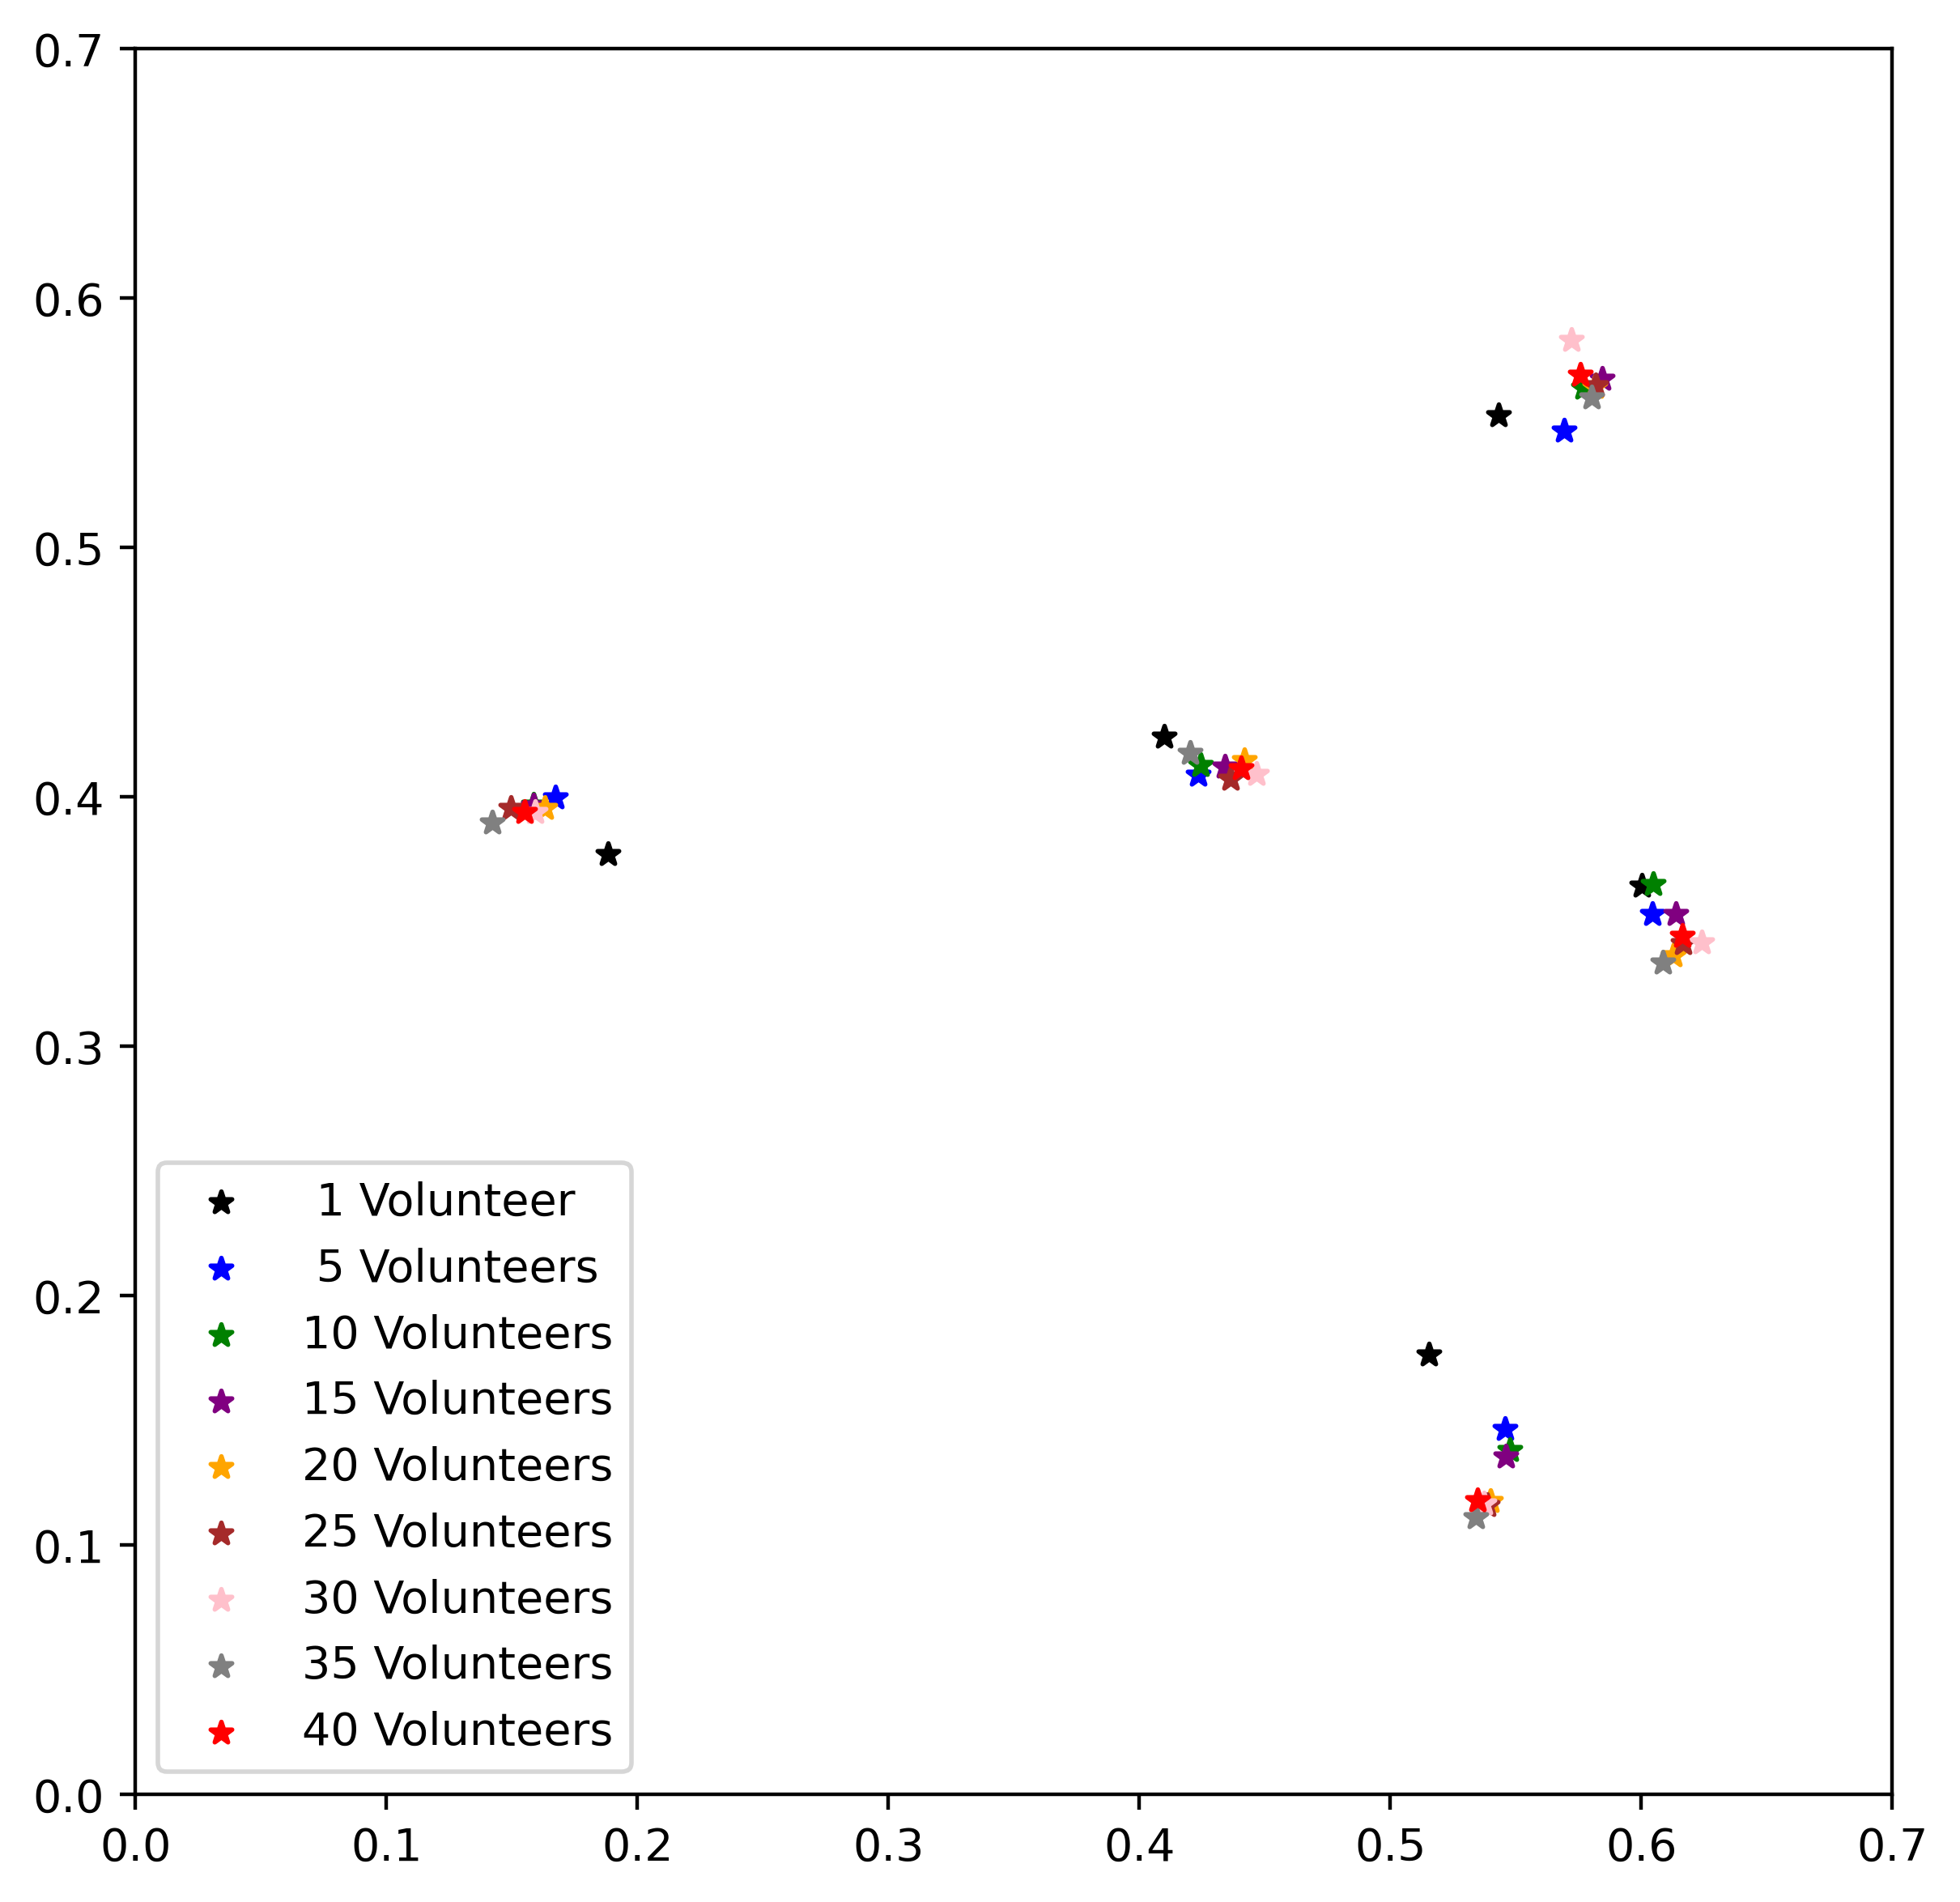

In [12]:

# Define the grid
x_grid = np.linspace(0, 0.7, 100)
y_grid = np.linspace(0, 0.7, 100)
x, y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([x.ravel(), y.ravel()])

# Evaluate KDE on the grid
# pdf = kde(grid_coords).reshape(100, 100)

# # Plot the KDE
# plt.rcParams['figure.dpi'] = 400
# plt.imshow(pdf, origin='lower', extent=(0, 0.7, 0, 0.7), aspect='auto', cmap='viridis')
# plt.colorbar(label='Density')
plt.rcParams['figure.dpi'] = 400
plt.figure(figsize=(7, 7))
plt.xlim(0, 0.7)
plt.ylim(0, 0.7)

# coor = [ 11, 2,16, 4,3, 6,11, 9, 17, 9,15, 12,5, 14,12, 16,17, 16]

# for i in range(int(len(coor)/2)):
#     x,y = coordinate(coor[i*2], coor[i*2+1],20)
#     plt.scatter(x,y, color='b', s = 10 )

temp =[0.18814771, 0.37707834 ,0.41001955, 0.42408543, 0.51534021 ,0.17638288,
 0.54325136, 0.55303994 ,0.60017426 ,0.36420374]


circle_num = 25




### Benchmark
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='black', s = circle_num,marker='*',label=" 1 Volunteer")





### Scenario 1

temp = [0.16716795 ,0.39971944 ,0.42335627 ,0.40864266, 0.54584206, 0.14658781,
 0.56912035, 0.54665065 ,0.60431341, 0.35285784]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='blue', s = circle_num,marker='*',label=" 5 Volunteers")


### Scenario 2

temp = [0.15847853, 0.39676634, 0.42432841, 0.41260495 ,0.54752039, 0.13792282,
 0.57684337, 0.56390849 ,0.60465054 ,0.36499027]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='green', s = circle_num,marker='*',label="10 Volunteers")


### Scenario 3

temp = [0.15872294 ,0.39659004, 0.434024,   0.41206502 ,0.54599528, 0.13553137,
 0.58423055 ,0.56743655 ,0.61380651 ,0.35294547]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='purple', s = circle_num,marker='*',label="15 Volunteers")


### Scenario 4

temp = [0.1629826,  0.39547274, 0.44186116, 0.4147244 , 0.5397551,  0.11751261,
 0.58149091 ,0.56419485 ,0.61276335 ,0.33639675]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='orange', s = circle_num,marker='*',label="20 Volunteers")


### Scenario 5

temp = [0.1494388 , 0.39553568 ,0.43620852, 0.40702685, 0.53857347, 0.11579757,
 0.58189216 ,0.56484293 ,0.6165934 , 0.34123952]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='brown', s = circle_num,marker='*',label="25 Volunteers")


### Scenario 6

temp = [0.15930905, 0.39378578, 0.4466247 , 0.40916131 ,0.53722818 ,0.11645823,
 0.57227986, 0.58320798 ,0.62415306, 0.34146615]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='pink', s = circle_num,marker='*',label="30 Volunteers")


### Scenario 7

temp = [0.14216609, 0.38965442 ,0.42018568, 0.41748059 ,0.53400069, 0.11116117,
 0.58032617, 0.5600142 , 0.60848232 ,0.33360946]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='gray', s = circle_num,marker='*',label="35 Volunteers")

### Scenario 8

temp =[0.15490008 ,0.39391132 ,0.44039495 ,0.41132995, 0.53485774 ,0.11783929,
 0.57567182 ,0.56905147 ,0.6161673 , 0.34429576]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='red', s = circle_num,marker='*',label="40 Volunteers")










# x,y = coordinate(5, 10,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(14, 5,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(15, 14,20)
# plt.scatter(x,y, color='b', s = 10 )
plt.legend(loc='lower left', fontsize= 10) 
# plt.title('Optimal Locations for ' + f'{num}' + ' AEDs with 10 Volunteers')
# plt.title('Sensitive Analysis of Volunteer Numbers for 5 AEDs')
plt.savefig("/Users/wuyifan1995/Downloads/SA_Volunteer.pdf", format='pdf')
plt.show()






### volunteer compare

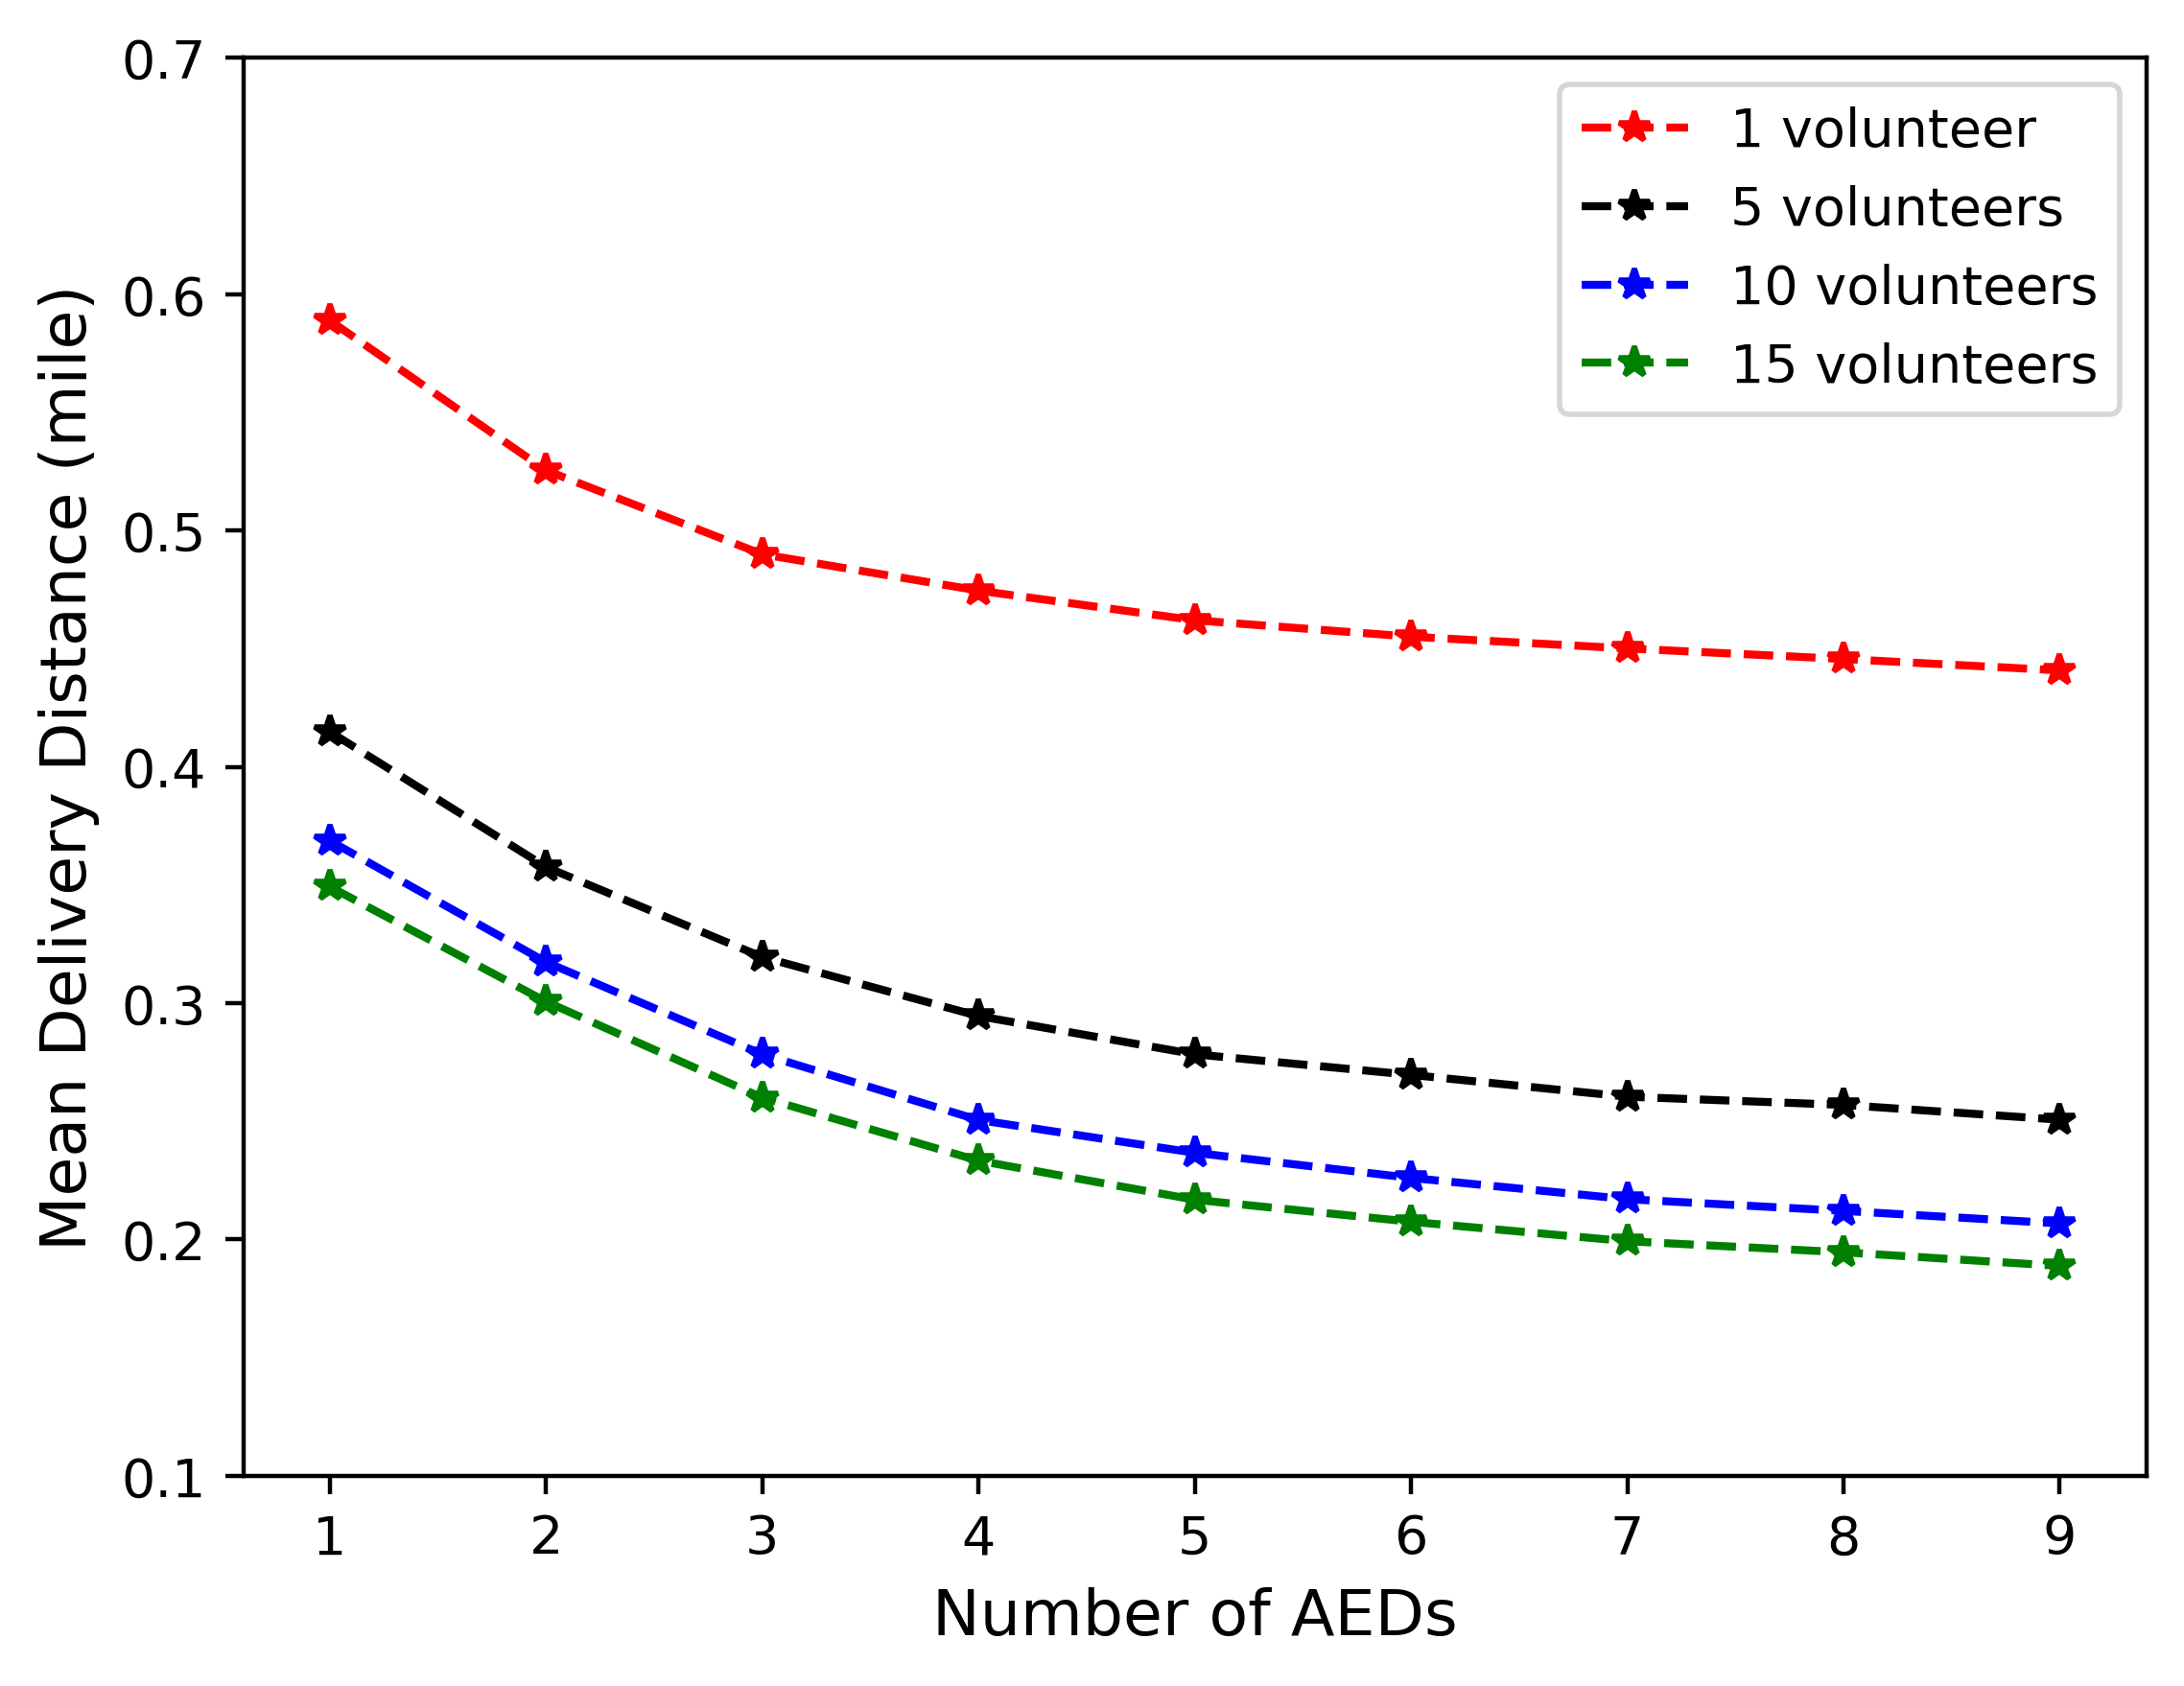

In [8]:




### Sample Size 5,000
# warm_obj = [0.6951925,0.5223432,0.4149615,0.3910766]
obj_1 = [0.588960,0.5254927,0.490017,0.4746320, 0.4620726,0.4551295,0.4501502, 0.4456717, 0.440870]

obj_5 = [0.4149202, 0.3576374,0.319564,0.2945812 ,0.2784039, 0.26969031,0.260448,0.2569788,0.250718 ]

obj_10 = [  0.36878516,0.3174360,0.2783847,0.250598,0.2367233, 0.22608897, 0.2170849,0.212125,0.206830 ]

obj_15 = [ 0.349355, 0.3007026, 0.260047, 0.233382 ,0.2168522,0.207532,0.1993029,0.194617,0.1888537 ]




plt.subplot()
plt.rcParams['figure.dpi'] = 400
x_plot = np.linspace(1,9,9)


plt.plot(x_plot, obj_1, "r*--", label="1 volunteer")
plt.plot(x_plot, obj_5, "k*--", label="5 volunteers")
plt.plot(x_plot, obj_10, "b*--", label="10 volunteers")
plt.plot(x_plot, obj_15, "g*--", label="15 volunteers")


plt.ylim([0.1, 0.7])
plt.xlabel('Number of AEDs',fontsize=12)
plt.ylabel('Mean Delivery Distance (mile)',fontsize=12)
# plt.title("Comparison of Objective Value")
# Set x-ticks to be integers
plt.xticks(np.arange(1, 10, 1))
plt.legend()


plt.savefig("/Users/wuyifan1995/Downloads/mdd.pdf", format='pdf')
plt.show()





### Volunteer Number

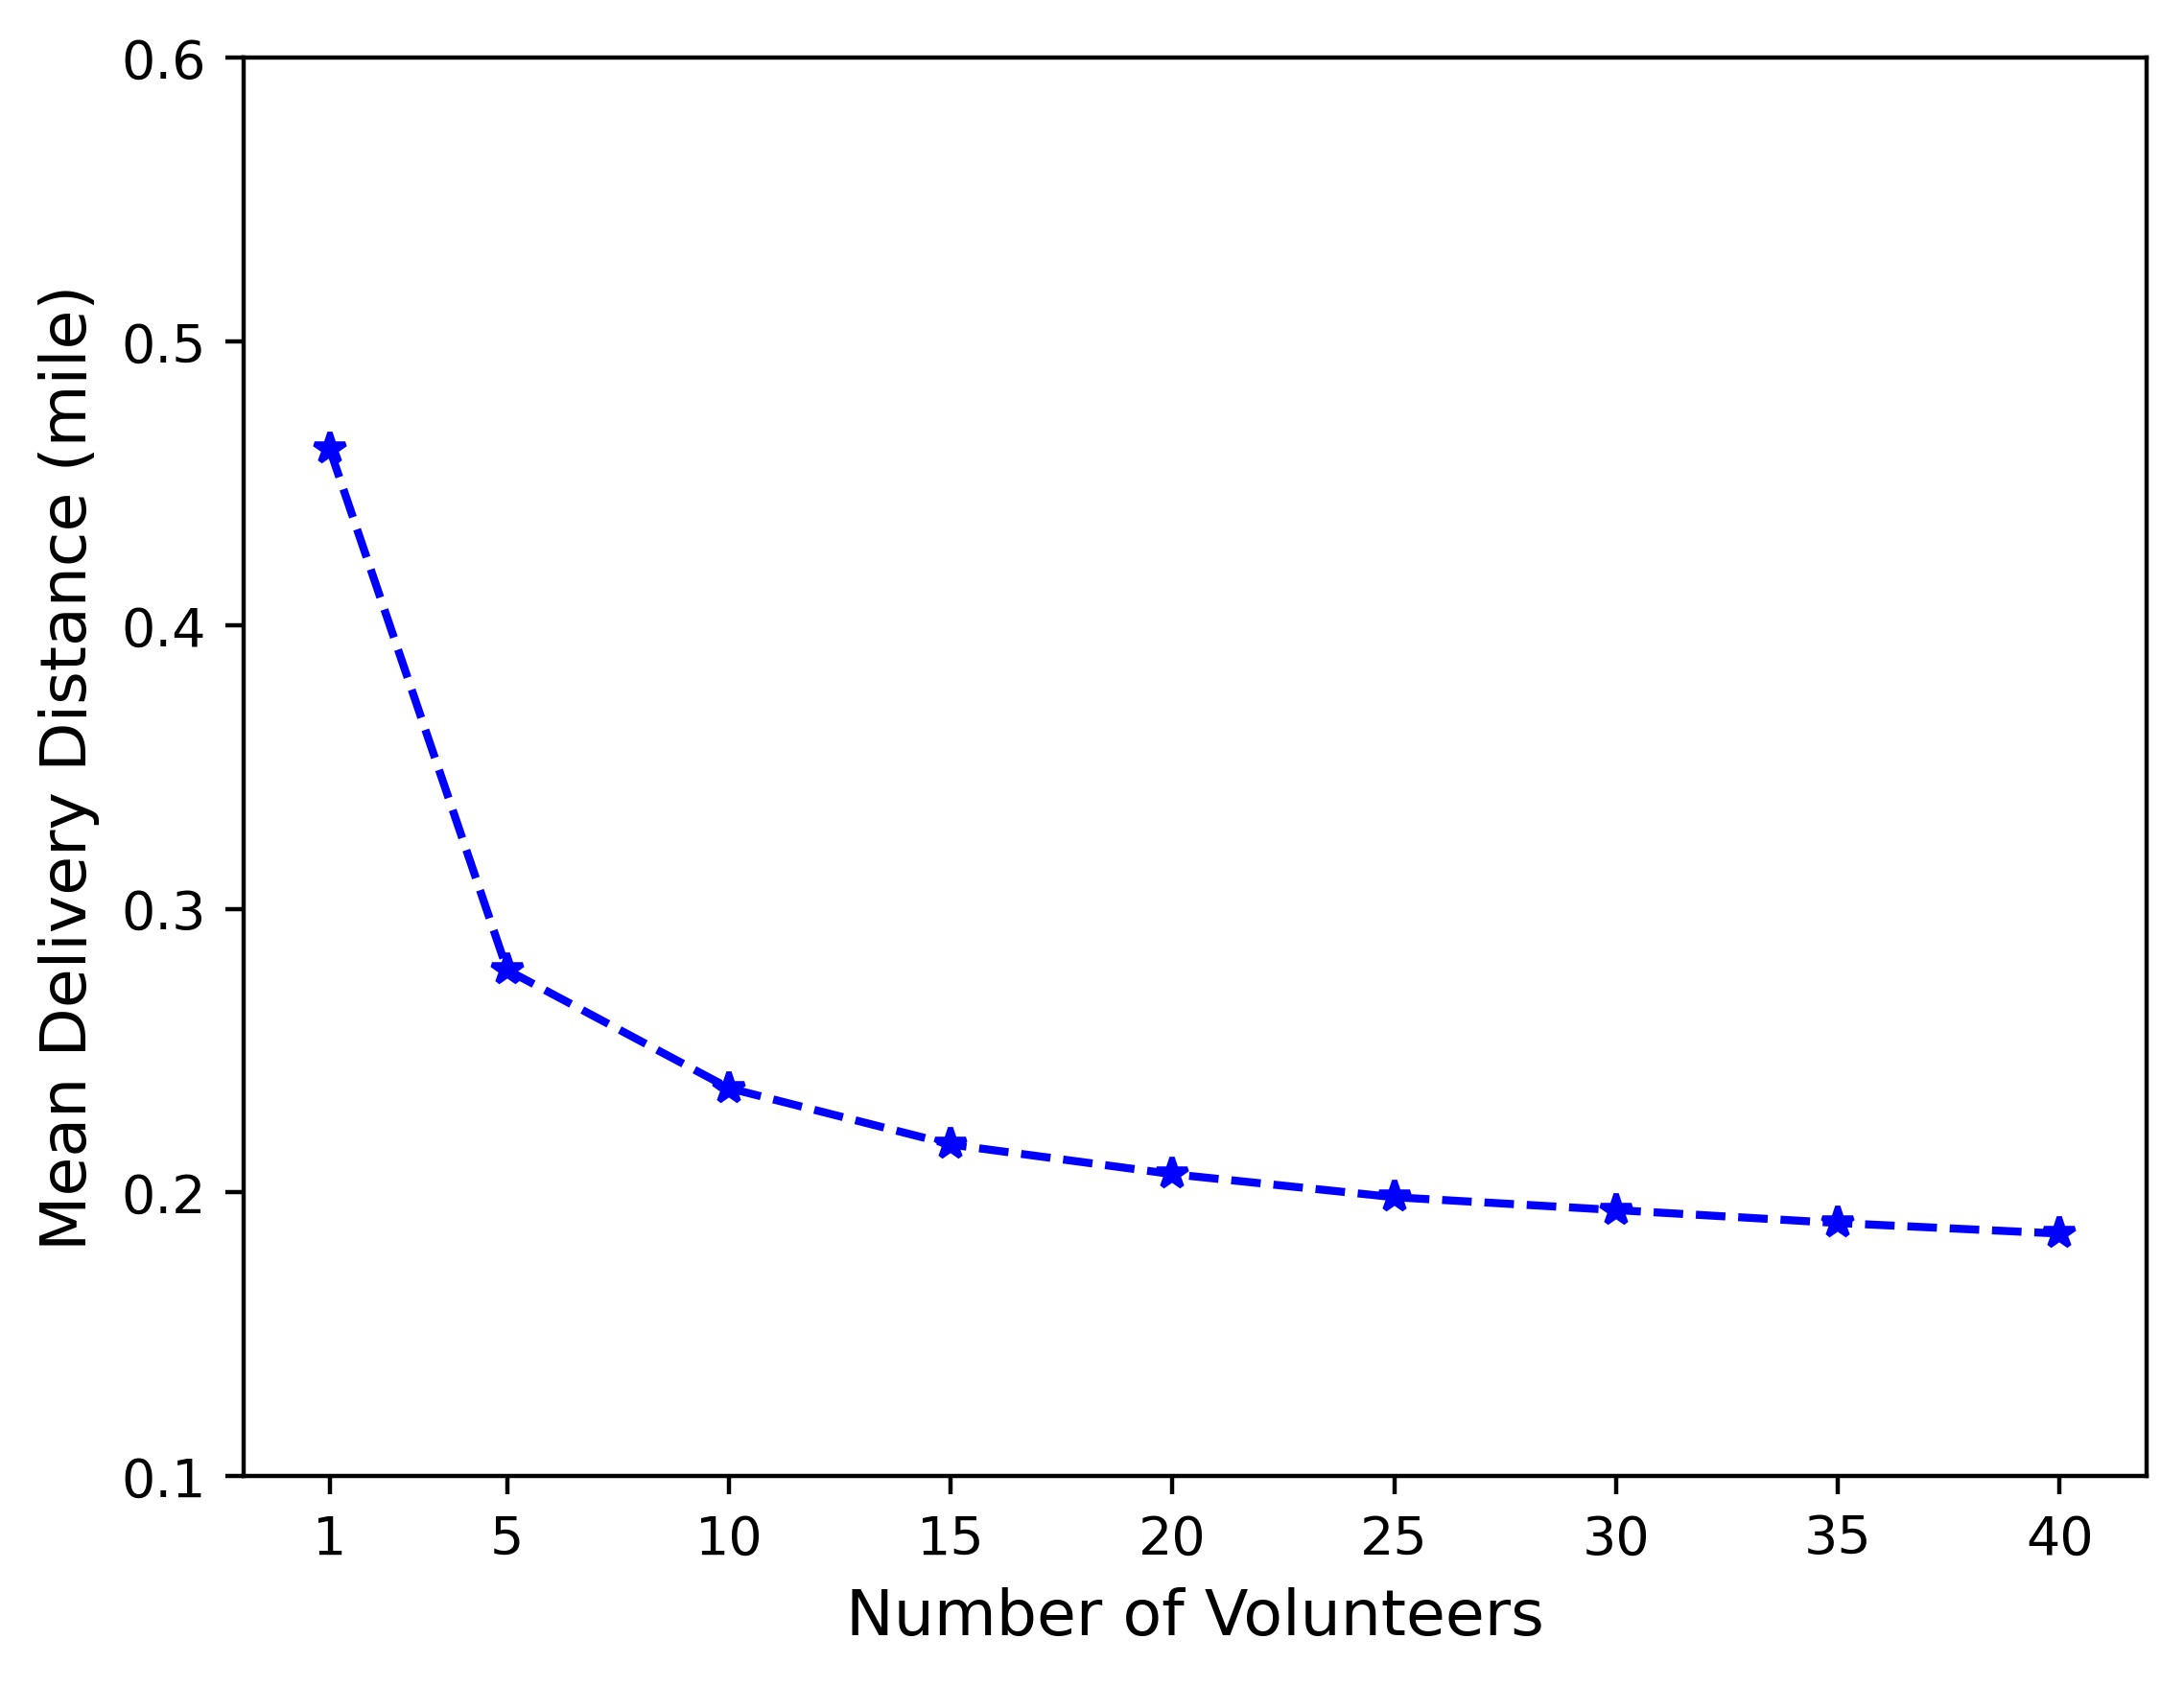

In [9]:
### Sample Size 5,000
# warm_obj = [0.6951925,0.5223432,0.4149615,0.3910766]
Bender_obj = [0.4620726, 0.2784039,0.236723, 0.216852, 0.2064008, 0.198269,0.1937302, 0.1891717, 0.185439  ]



plt.subplot()
plt.rcParams['figure.dpi'] = 400
x_plot = [1, 5,10,15,20,25,30,35,40]


plt.plot(x_plot, Bender_obj, "b*--")





plt.ylim([0.1, 0.6])
plt.xlabel('Number of Volunteers',fontsize=12)
plt.ylabel('Mean Delivery Distance (mile)',fontsize=12)
# plt.title("Comparison of Objective Value with 5 AEDs")
# Set x-ticks to be integers
# plt.xticks(np.arange(5, 45, 5))
plt.xticks([1, 5,10,15,20,25,30,35,40])

plt.savefig("/Users/wuyifan1995/Downloads/mdd_volunteer.pdf", format='pdf')

plt.show()


### Contour of 5 AEDs

In [5]:


def contour_value(X, Y, eval_solution, volunteer_number):
	sample_num = 1000
	
	# Initialize an empty result array
	Z = np.zeros(X.shape)
	
	# Loop through each point in the grid
	for i in range(X.shape[0]):
		for j in range(X.shape[1]):
			x = X[i, j]
			y = Y[i, j]
			data = np.tile([x, y], (sample_num, 1))
			df = pd.DataFrame(data, columns=['X', 'Y'])
			sample_df = construct_sample(df, volunteer_number)
			temp_result = evaluate_obj(sample_df, eval_solution)
			Z[i, j] = temp_result

	return Z


eval_solution = [0.15847853, 0.39676634, 0.42432841, 0.41260495 ,0.54752039, 0.13792282,
 0.57684337, 0.56390849 ,0.60465054 ,0.36499027]

# eval_solution =[0.18814771, 0.37707834 ,0.41001955, 0.42408543, 0.51534021 ,0.17638288,
#  0.54325136, 0.55303994 ,0.60017426 ,0.36420374]
volunteer_number = 10

# Create a grid of x and y values
num_points = 50
x = np.linspace(0, 0.7, num_points)
y = np.linspace(0, 0.7, num_points)
X, Y = np.meshgrid(x, y)

# Evaluate the function on the grid

Z = contour_value(X,Y,eval_solution,volunteer_number)




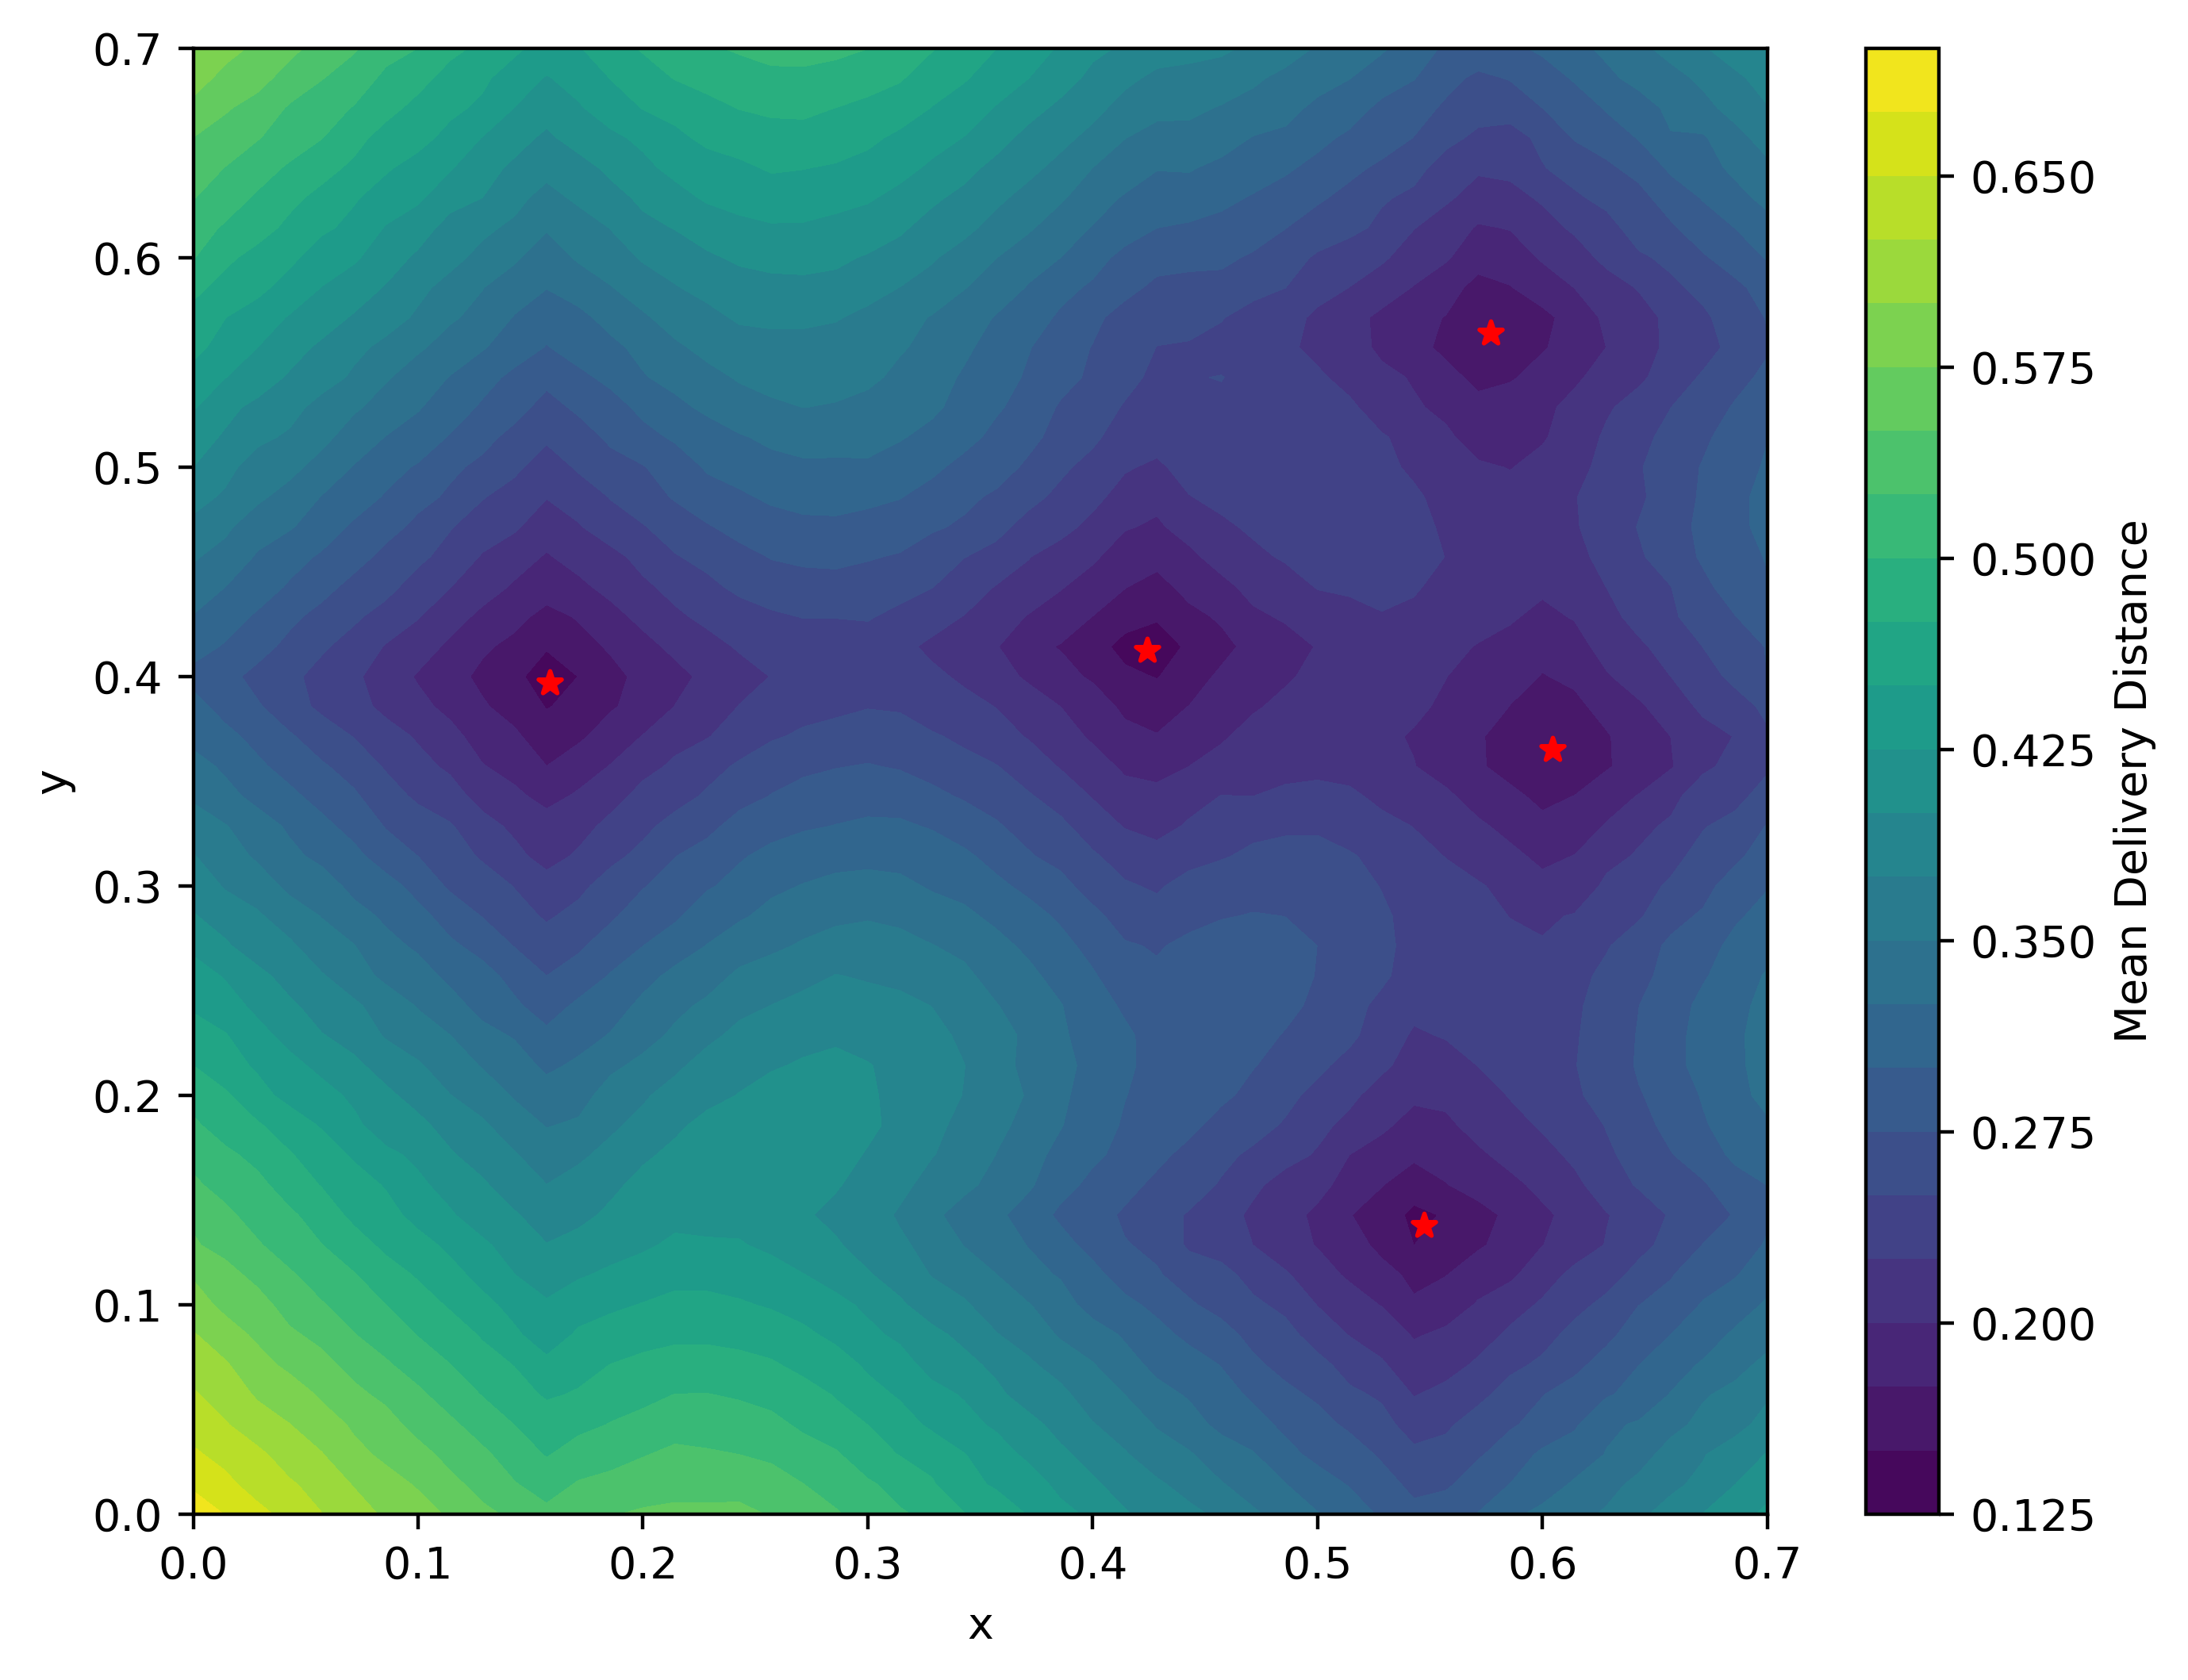

In [11]:


	
# Plot the contour map
plt.figure(figsize=(8, 6))

plt.rcParams['figure.dpi'] = 400
	

contour = plt.contourf(X, Y, Z, cmap='viridis', levels=25)
plt.colorbar(label='Mean Delivery Distance')
num = int(len(eval_solution)/2)
for i in range(int(len(eval_solution)/2)):
	x = eval_solution[i*2]
	y = eval_solution[i*2+1]
	plt.scatter(x,y, color='red', s = 30,marker='*')
	
plt.xlim(0, 0.7)
plt.ylim(0, 0.7)

# plt.title("Mean Distance Contour Map of " + f"{num}" + " AEDs with " + f"{volunteer_number}" + " Volunteers")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Sensitive Analysis 

### Construct Population

In [3]:
population = [12000, 5000, 18000, 14000]
sum_pop = sum(population)
original_list = [0,1,2,3]
pecent = 0.5

for i in range(4):
	delta = population[i]*pecent
	new_pop = np.zeros(4)
	new_pop[i] = population[i] + delta
	new_list = [item for item in original_list if item != i]
	sum_left = sum_pop - population[i]
	for index in new_list:
		proportion = population[index] / sum_left
		new_pop[index] = population[index] - delta * proportion
	
	new_pop = [round(item) for item in new_pop]
	print(new_pop )
	
	new_pop = np.zeros(4)
	new_pop[i] = population[i] - delta
	new_list = [item for item in original_list if item != i]
	sum_left = sum_pop - population[i]
	for index in new_list:
		proportion = population[index] / sum_left
		new_pop[index] = population[index] + delta * proportion
	
	new_pop = [round(item) for item in new_pop]
	print(new_pop )



[18000, 4189, 15081, 11730]
[6000, 5811, 20919, 16270]
[11318, 7500, 16977, 13205]
[12682, 2500, 19023, 14795]
[8516, 3548, 27000, 9935]
[15484, 6452, 9000, 18065]
[9600, 4000, 14400, 21000]
[14400, 6000, 21600, 7000]


### Experiments

### Bench Evaluation

In [234]:
eval_solution = [0.16569062, 0.39814528 ,0.43492666 ,0.4134408 , 0.5465748,  0.12693656, 0.5789898  ,0.55944317, 0.60589216 ,0.33748879]
volunteer_number = 10
print("The hubs number is ", len(eval_solution)/2)
print("The volunteer number is: ", volunteer_number)
post_evaluation(eval_solution,volunteer_number)

The hubs number is  5.0
The volunteer number is:  10
The Eval objective function is 0.2652451622867436


0.2652451622867436

In [235]:
P_number = 5
volunteer_num = 10
print("+++++++++++++++ ")
print("Number of Hub is: ", P_number)
yvalues_h = direct_10(P_number,volunteer_num)

+++++++++++++++ 
Number of Hub is:  5
Number of  volunteer is  10
Set parameter MIPGap to value 0
running time is  845.6577389240265
P(3, 8)
P(10, 13)
P(13, 3)
P(16, 9)
P(16, 15)


The hub number is  5.0
[0.1225 0.2975 0.3675 0.4725 0.4725 0.1225 0.5775 0.3325 0.5775 0.5425]
++++++++++++++++++
Number of  volunteer is  10
The initial objective function is 0.26202445458984913
The final objective function is 0.26097269275807006
It is converge
[0.14424302 0.31827312 0.40803696 0.47383209 0.48178034 0.13042904
 0.58368995 0.33663596 0.5718048  0.56301748]
------ Time Elapsed 1068.18021774292 seconds ------


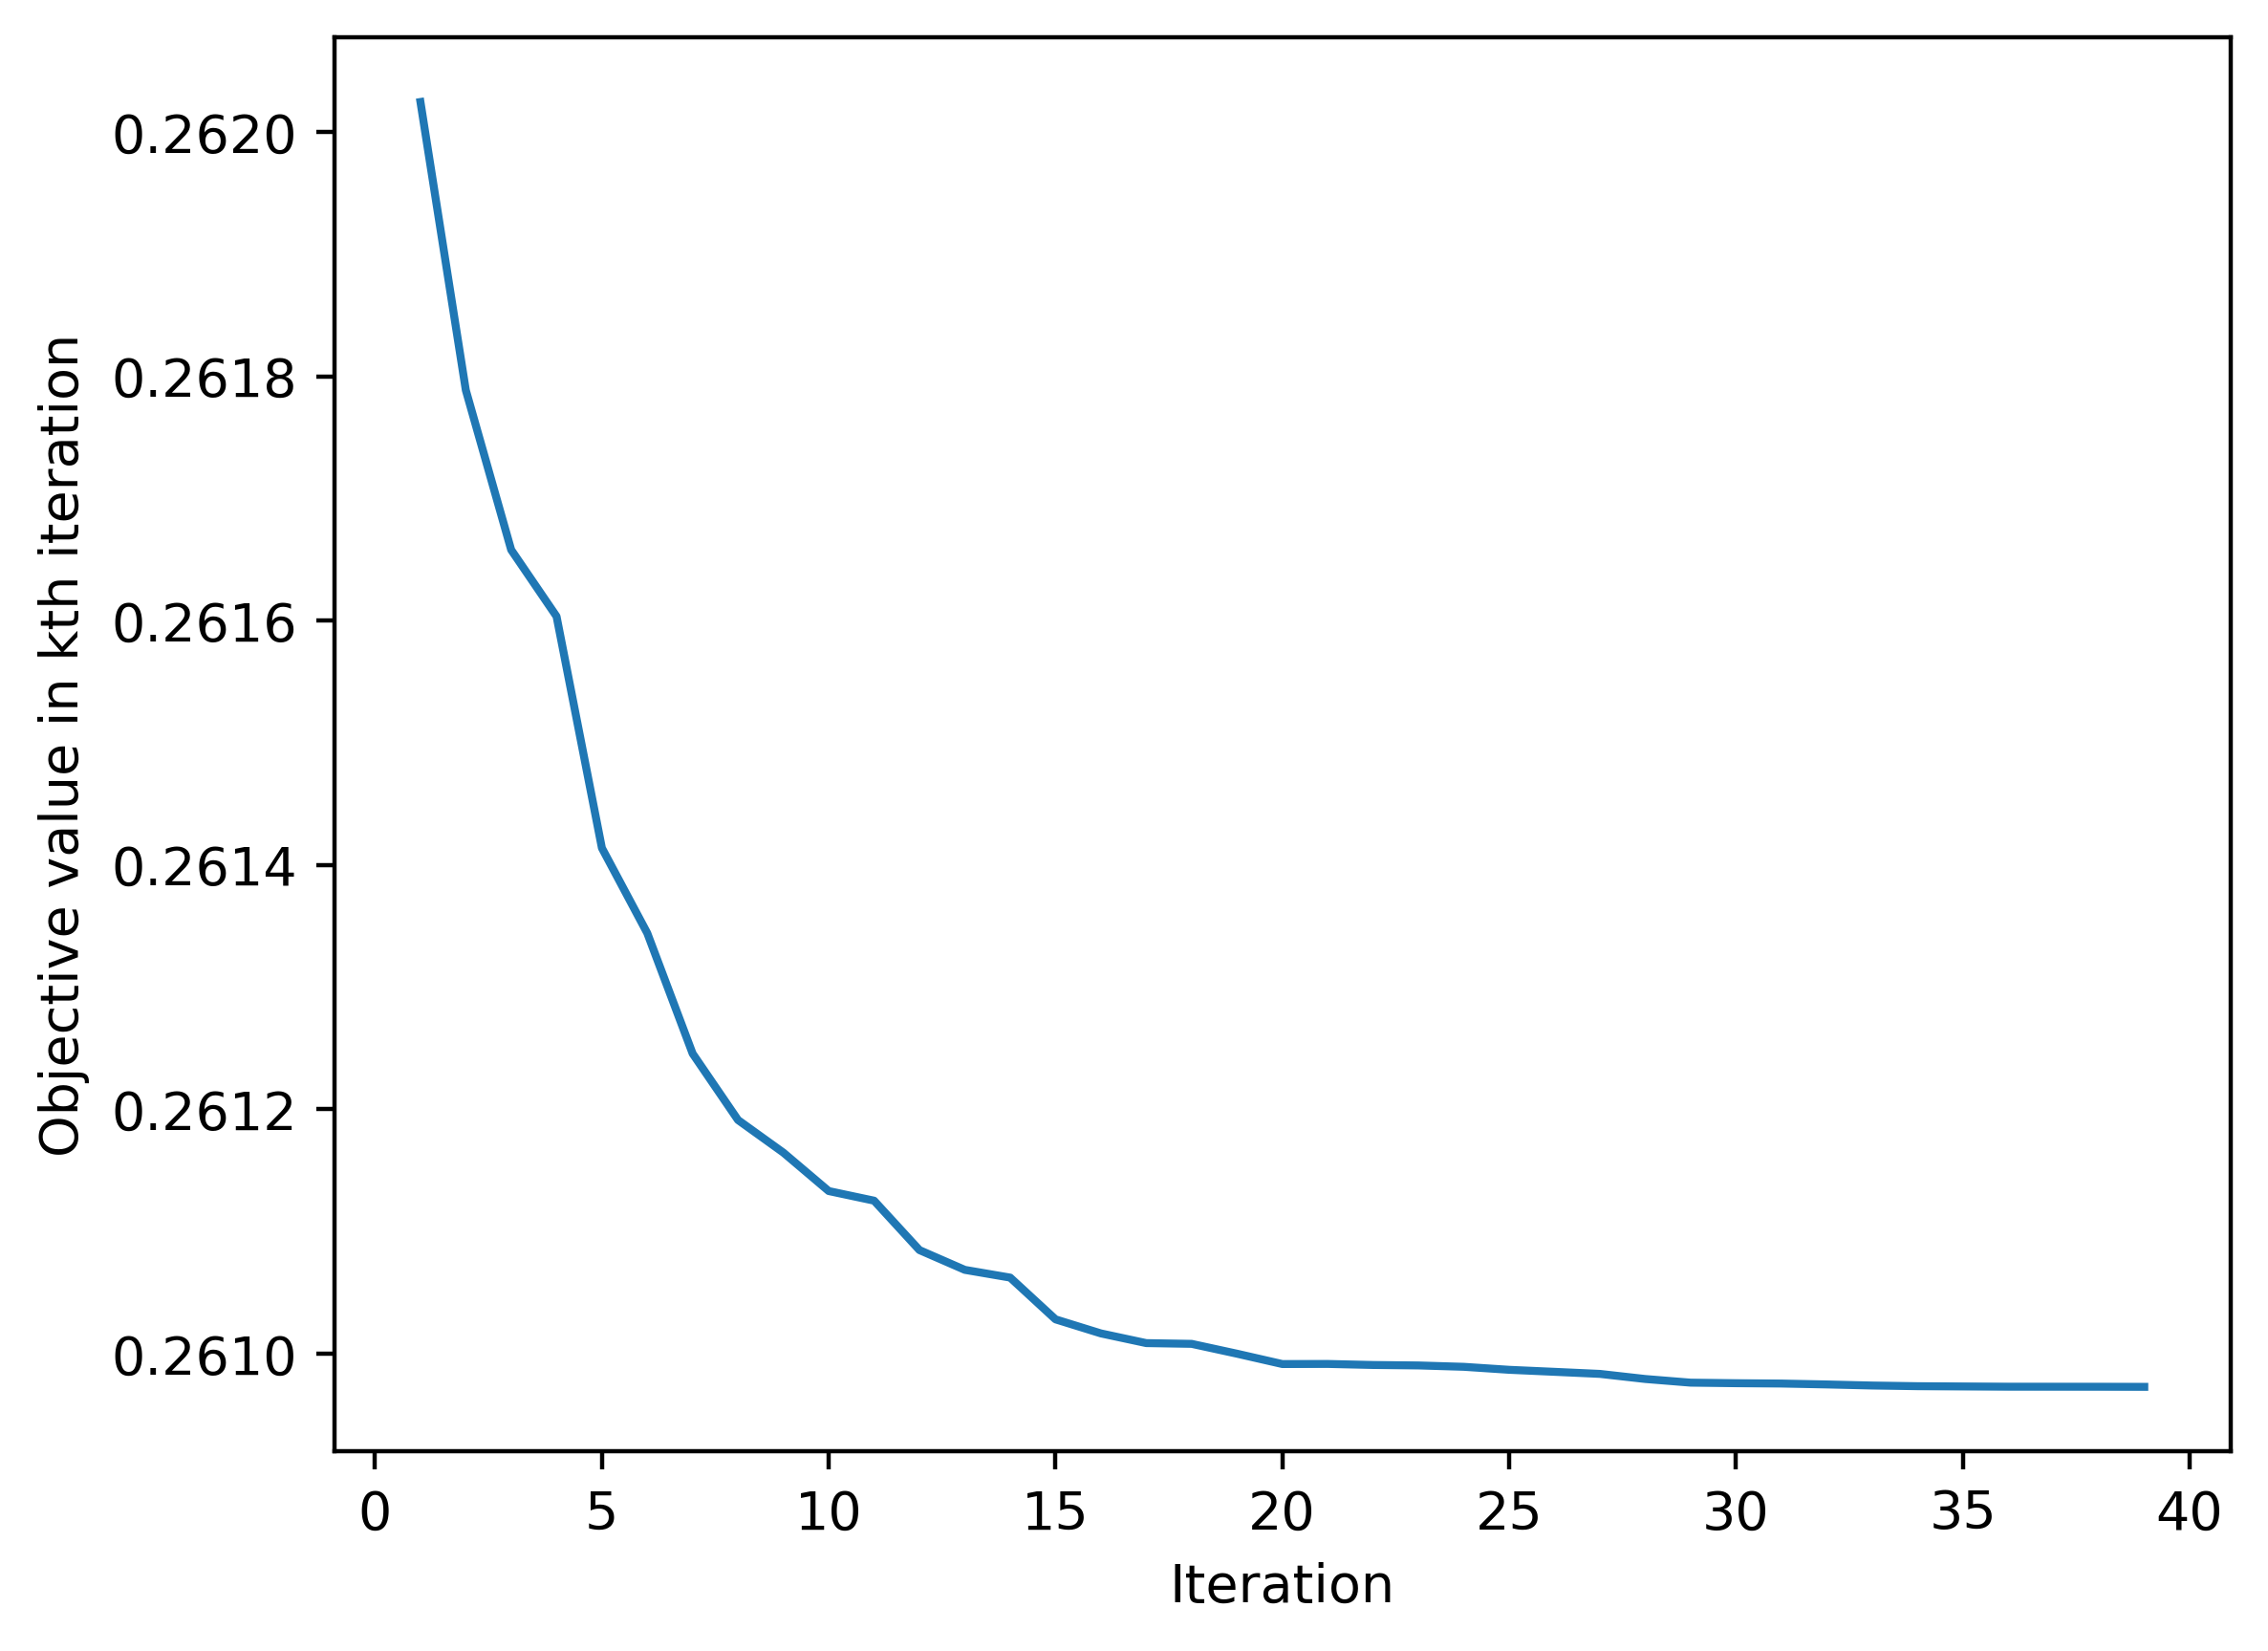

In [236]:
# bender_solution =  [4, 11,12, 11,15, 3,16, 15,17, 9]
bender_solution =  [3, 8,10, 13, 13, 3,16, 9 ,16, 15]


volunteer_number = 10
step = 0.005# the initial desired magnitude of change in the theta elements
initial_solution = Bender_solution_trans(bender_solution,20)

print("The hub number is ", len(bender_solution)/2)
print(initial_solution)
print("++++++++++++++++++")
gavg = 4
iter_number = 200

start_time = time.time()
optimal_solution_bender, obj_track,current_obj,iter_SPSA,unconverge_flag = SPSA_optimization(initial_solution,volunteer_number,gavg,iter_number,step)

if unconverge_flag == 1:
	print("It is unconverge")
else:
	print("It is converge")
	
Reward_print_average(obj_track)
print(optimal_solution_bender)
print("------ Time Elapsed %s seconds ------" % (time.time() - start_time))

### Evaluation

In [239]:
eval_solution =     [0.14424302,0.31827312 ,0.40803696 ,0.47383209 ,0.48178034 ,0.13042904,0.58368995, 0.33663596 ,0.5718048 , 0.56301748]
volunteer_number = 10
print("The hubs number is ", len(eval_solution)/2)
print("The volunteer number is: ", volunteer_number)
post_evaluation(eval_solution,volunteer_number)

The hubs number is  5.0
The volunteer number is:  10
The Eval objective function is 0.2620218836830563


0.2620218836830563

### Plot of 10%

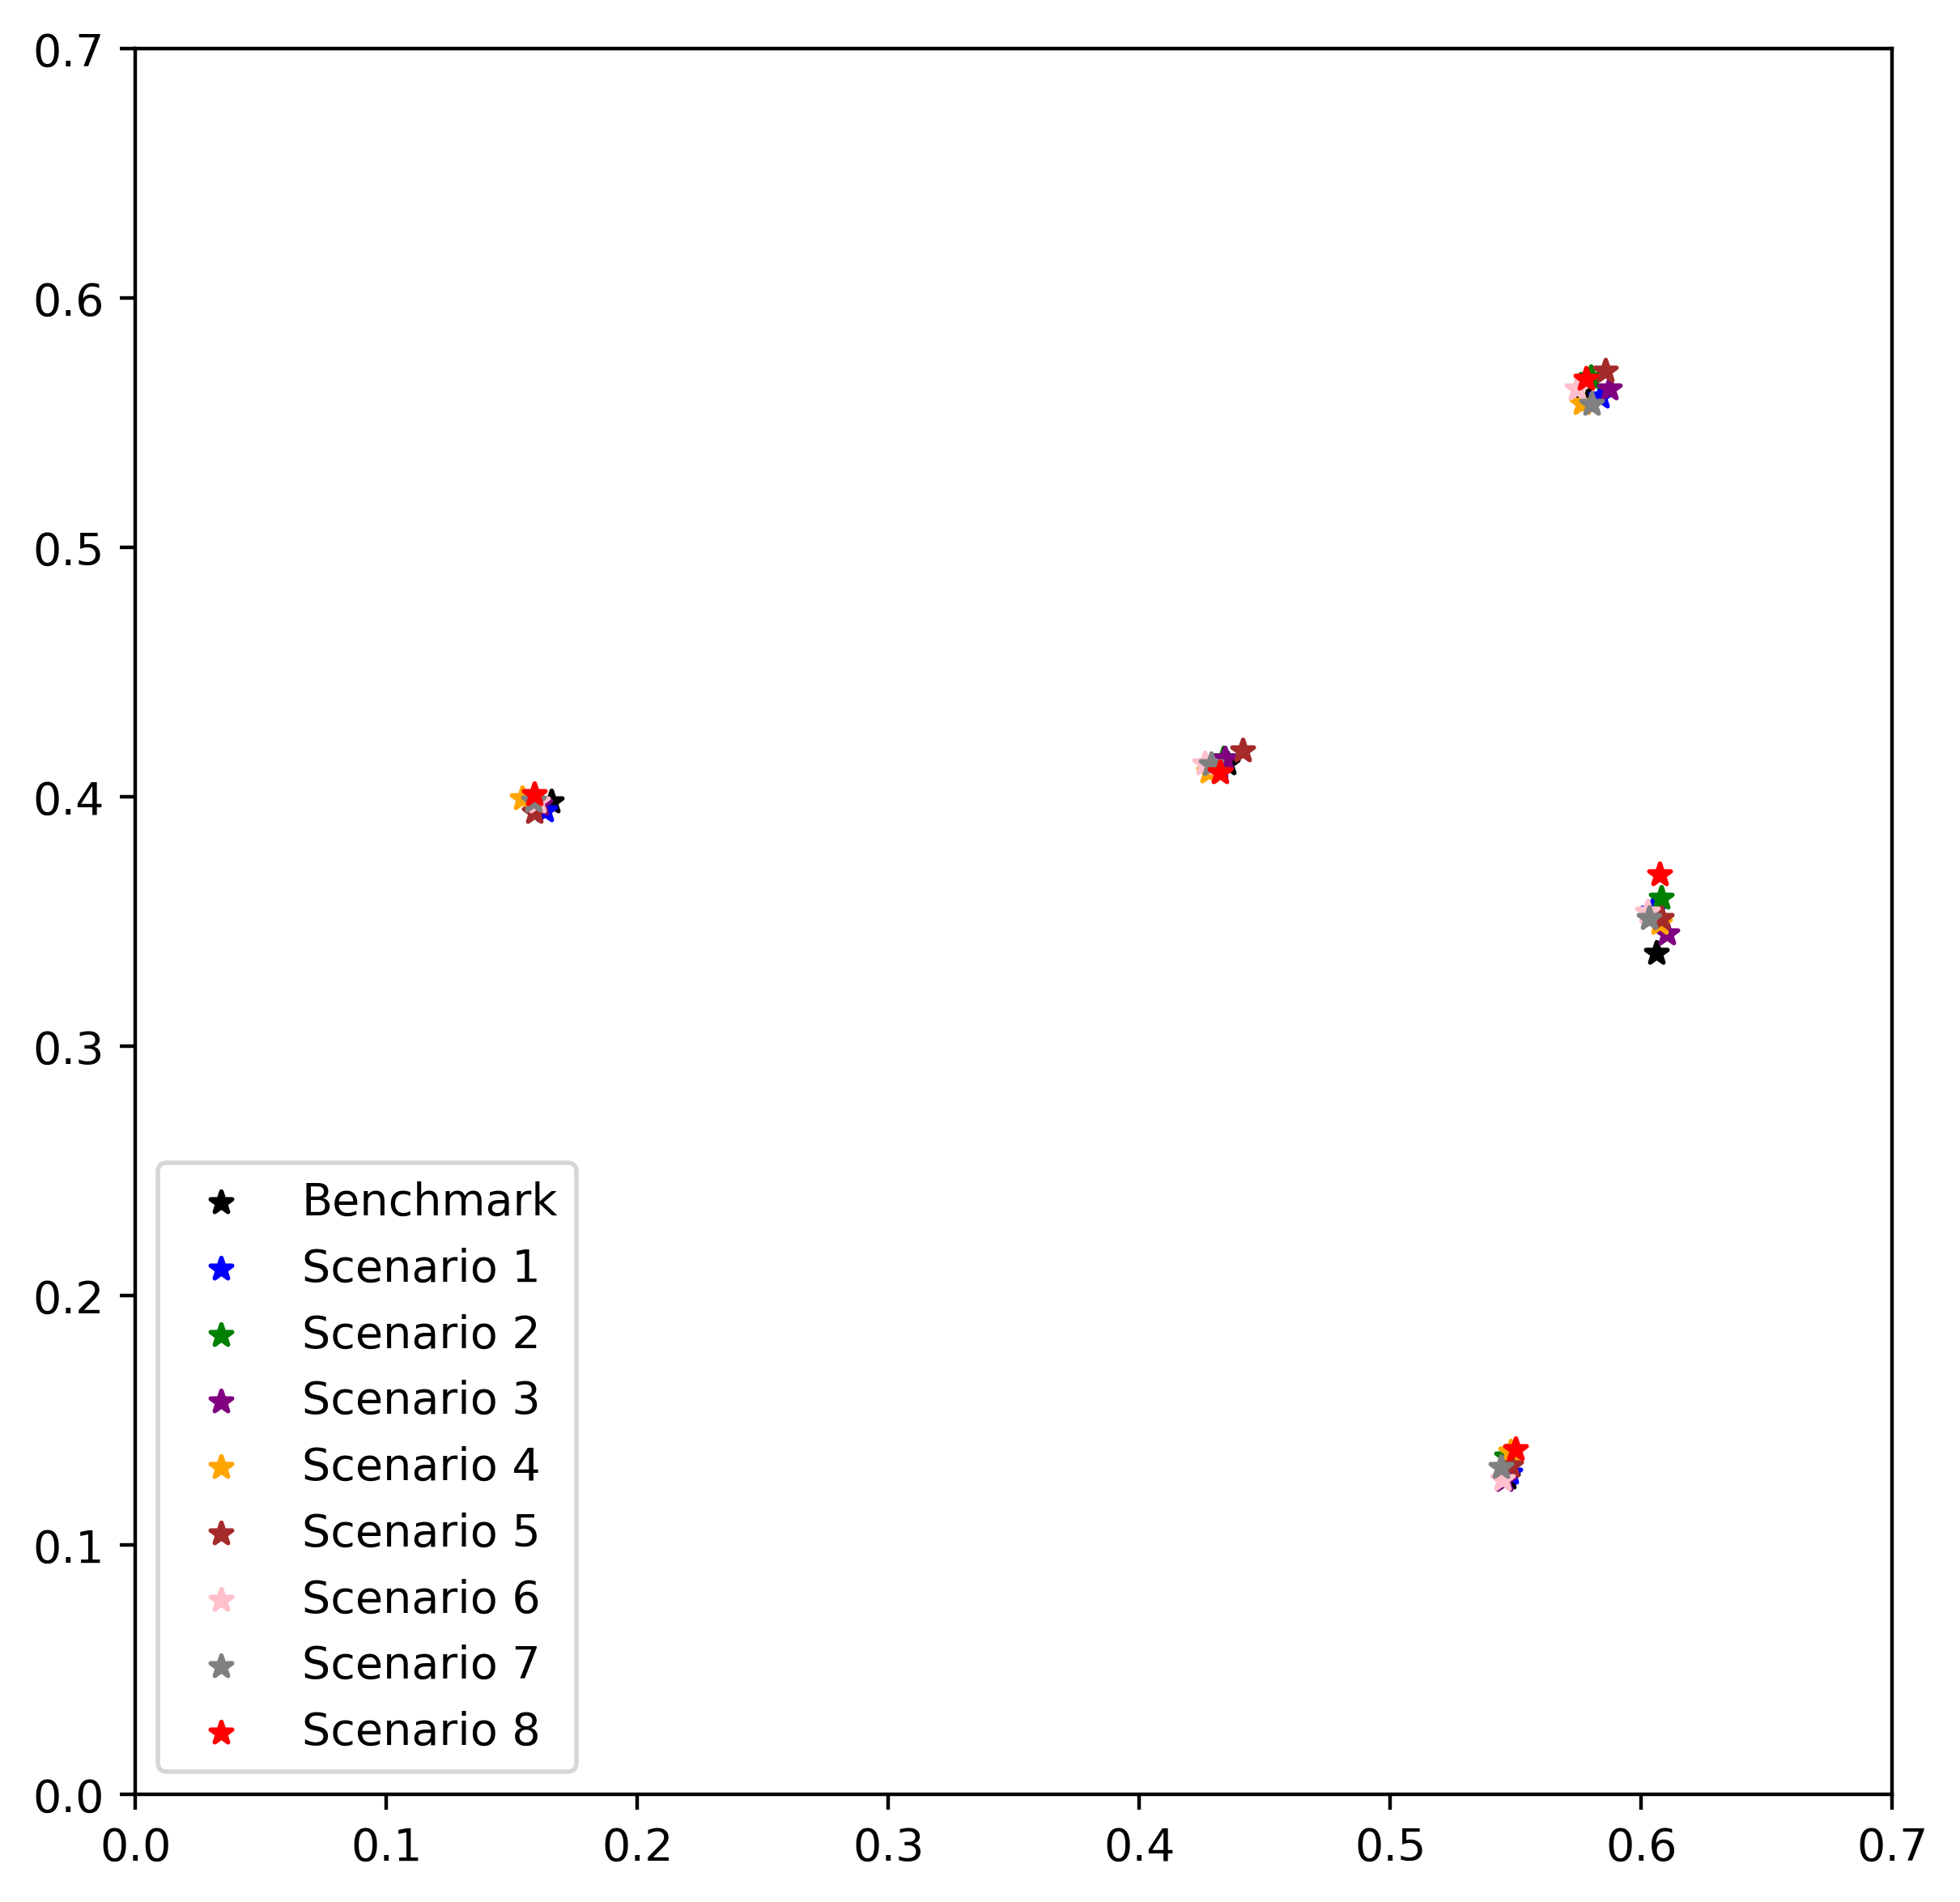

In [10]:
df = pd.read_csv('relative_coordinates.csv')
column1 = df['Rotated_Longitude_miles'].values
column2 = df['Rotated_Latitude_miles'].values
data = np.column_stack((column1, column2))
# Perform KDE
kde = gaussian_kde(data.T)

# Define the grid
x_grid = np.linspace(0, 0.7, 100)
y_grid = np.linspace(0, 0.7, 100)
x, y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([x.ravel(), y.ravel()])

# Evaluate KDE on the grid
# pdf = kde(grid_coords).reshape(100, 100)

# # Plot the KDE
# plt.rcParams['figure.dpi'] = 400
# plt.imshow(pdf, origin='lower', extent=(0, 0.7, 0, 0.7), aspect='auto', cmap='viridis')
# plt.colorbar(label='Density')

plt.figure(figsize=(7, 7))
plt.xlim(0, 0.7)
plt.ylim(0, 0.7)

# coor = [ 11, 2,16, 4,3, 6,11, 9, 17, 9,15, 12,5, 14,12, 16,17, 16]

# for i in range(int(len(coor)/2)):
#     x,y = coordinate(coor[i*2], coor[i*2+1],20)
#     plt.scatter(x,y, color='b', s = 10 )

temp =[0.16569062, 0.39814528 ,0.43492666 ,0.4134408 , 0.5465748,  0.12693656,
 0.5789898  ,0.55944317, 0.60589216 ,0.33748879]


circle_num = 25




### Benchmark
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='black', s = circle_num,marker='*',label="Benchmark")





### Scenario 1

temp = [0.16318639, 0.39467544, 0.43175058, 0.41170246, 0.54766189 ,0.12906244,
 0.58386845, 0.56034326 ,0.60434062, 0.35429777]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='blue', s = circle_num,marker='*',label="Scenario 1")


### Scenario 2

temp = [0.15959509 ,0.39799863 ,0.43349728 ,0.41544265, 0.54622058, 0.13535346,
 0.57981841, 0.56833111, 0.60783356, 0.35942119]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='green', s = circle_num,marker='*',label="Scenario 2")


### Scenario 3

temp = [0.16114524, 0.39720161 ,0.43407188 ,0.41530893, 0.5452845 , 0.12607018,
 0.58720954 ,0.56382925, 0.61027023 ,0.34505166]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='purple', s = circle_num,marker='*',label="Scenario 3")


### Scenario 4

temp = [0.15391405, 0.39933595 ,0.42759043 ,0.41018721 ,0.5480693 , 0.13725016,
 0.576263 ,  0.55794234, 0.60716265 ,0.34933033]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='orange', s = circle_num,marker='*',label="Scenario 4")


### Scenario 5

temp = [0.15889922, 0.39379177 ,0.44119451, 0.41867157, 0.54799729, 0.13193053,
 0.58558395 ,0.57074449, 0.60800188 ,0.35144145]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='brown', s = circle_num,marker='*',label="Scenario 5")


### Scenario 6

temp = [0.16035438, 0.39804533, 0.42589617, 0.41349106, 0.54483606, 0.12642366,
 0.5743484,  0.56368737 ,0.60243359, 0.35379672]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='pink', s = circle_num,marker='*',label="Scenario 6")


### Scenario 7

temp = [0.15857534, 0.39834149, 0.42845913, 0.41318231, 0.54406414 ,0.13119246,
 0.58005456 ,0.5574128 , 0.60317234 ,0.35130609]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='gray', s = circle_num,marker='*',label="Scenario 7")

### Scenario 8

temp = [0.15882968,0.40086103, 0.43213641, 0.40974174, 0.54982947 ,0.1383686,
 0.57782128, 0.56765061 ,0.60738134 ,0.36892888]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='red', s = circle_num,marker='*',label="Scenario 8")










# x,y = coordinate(5, 10,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(14, 5,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(15, 14,20)
# plt.scatter(x,y, color='b', s = 10 )
plt.legend(loc='lower left', fontsize= 10) 
# plt.title('Optimal Locations for ' + f'{num}' + ' AEDs with 10 Volunteers')
# plt.title('AEDs Locations for 10% adjustment')

plt.savefig("/Users/wuyifan1995/Downloads/Sensitive_10.pdf", format='pdf')
plt.show()






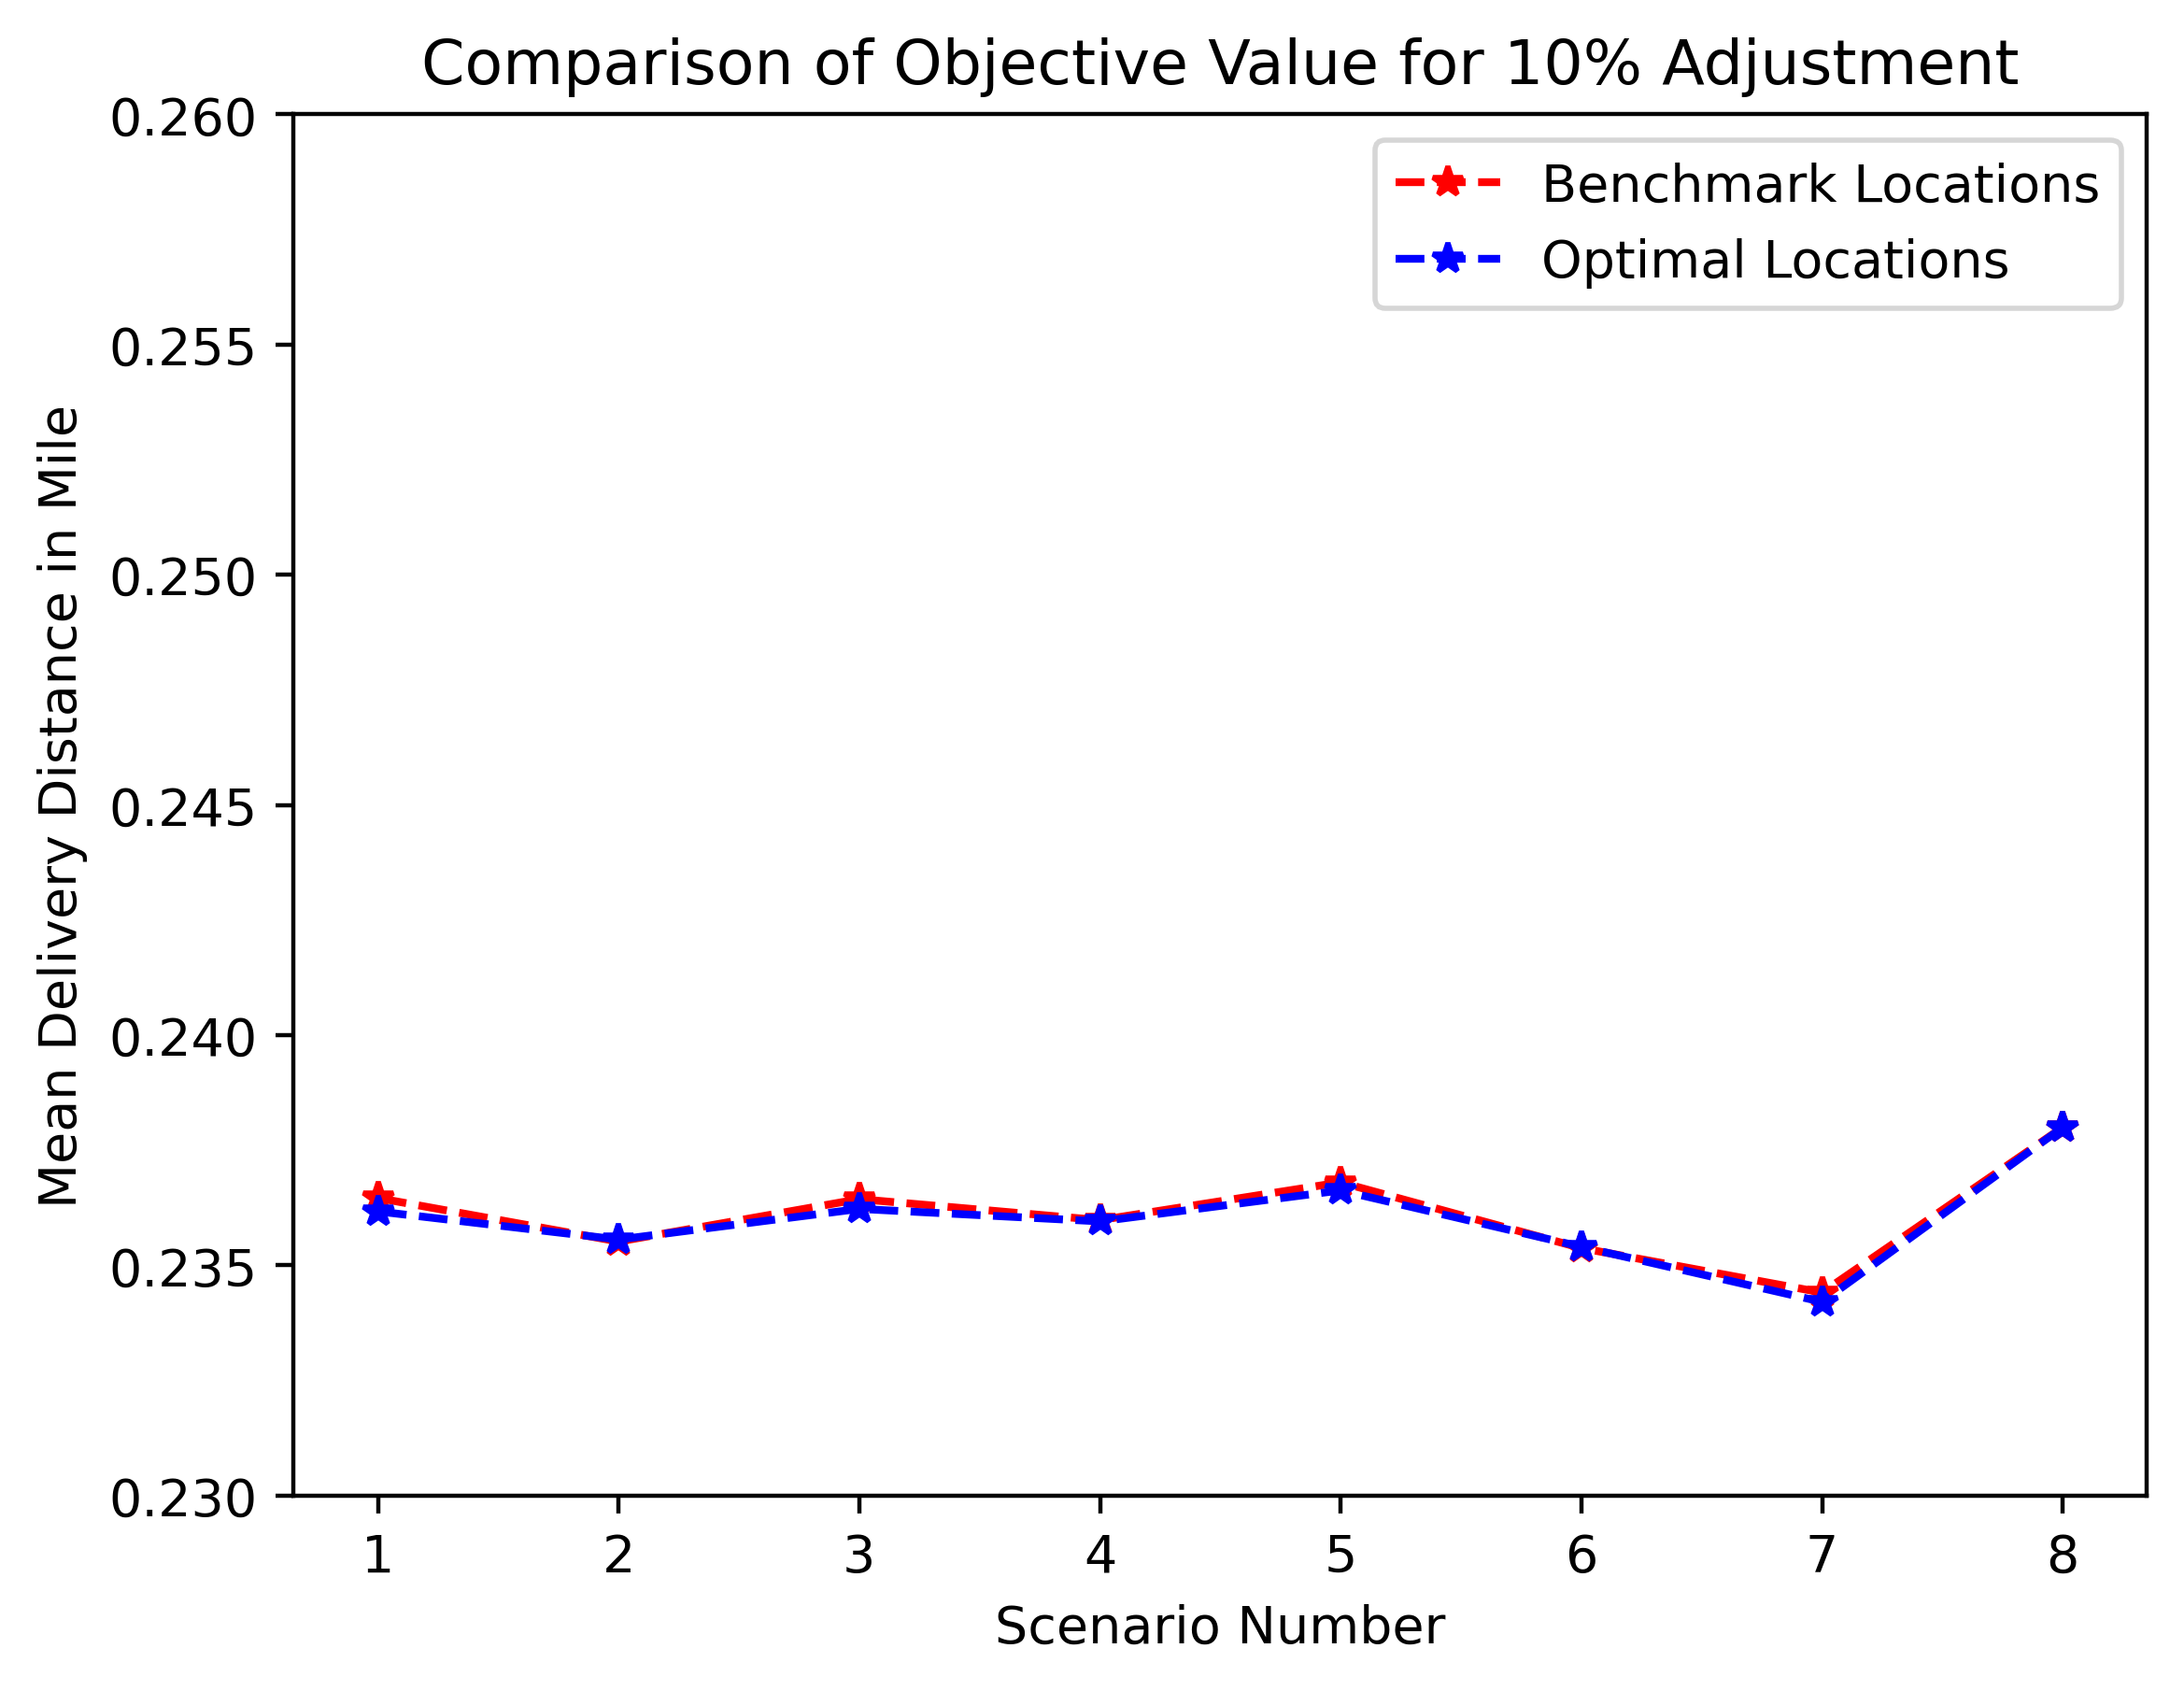

In [196]:




### Sample Size 5,000
# warm_obj = [0.6951925,0.5223432,0.4149615,0.3910766]
Benchmark = [0.236464,0.23551891,  0.2364406 , 0.2359847, 0.2368050,0.235376,0.2344106,0.2380]
obj = [  0.236173,0.2355626, 0.2362282, 0.2359567,0.2366289,0.2354046,0.234208,0.2380  ]




plt.subplot()
plt.rcParams['figure.dpi'] = 400
x_plot = np.linspace(1,8,8)


plt.plot(x_plot, Benchmark, "r*--", label="Benchmark Locations")
plt.plot(x_plot, obj, "b*--", label="Optimal Locations")



plt.ylim([0.23, 0.26])
plt.xlabel('Scenario Number')
plt.ylabel('Mean Delivery Distance in Mile')
plt.title("Comparison of Objective Value for 10% Adjustment")
# Set x-ticks to be integers
plt.xticks(np.arange(1, 9, 1))
plt.legend()
plt.show()





### Plot of 50%

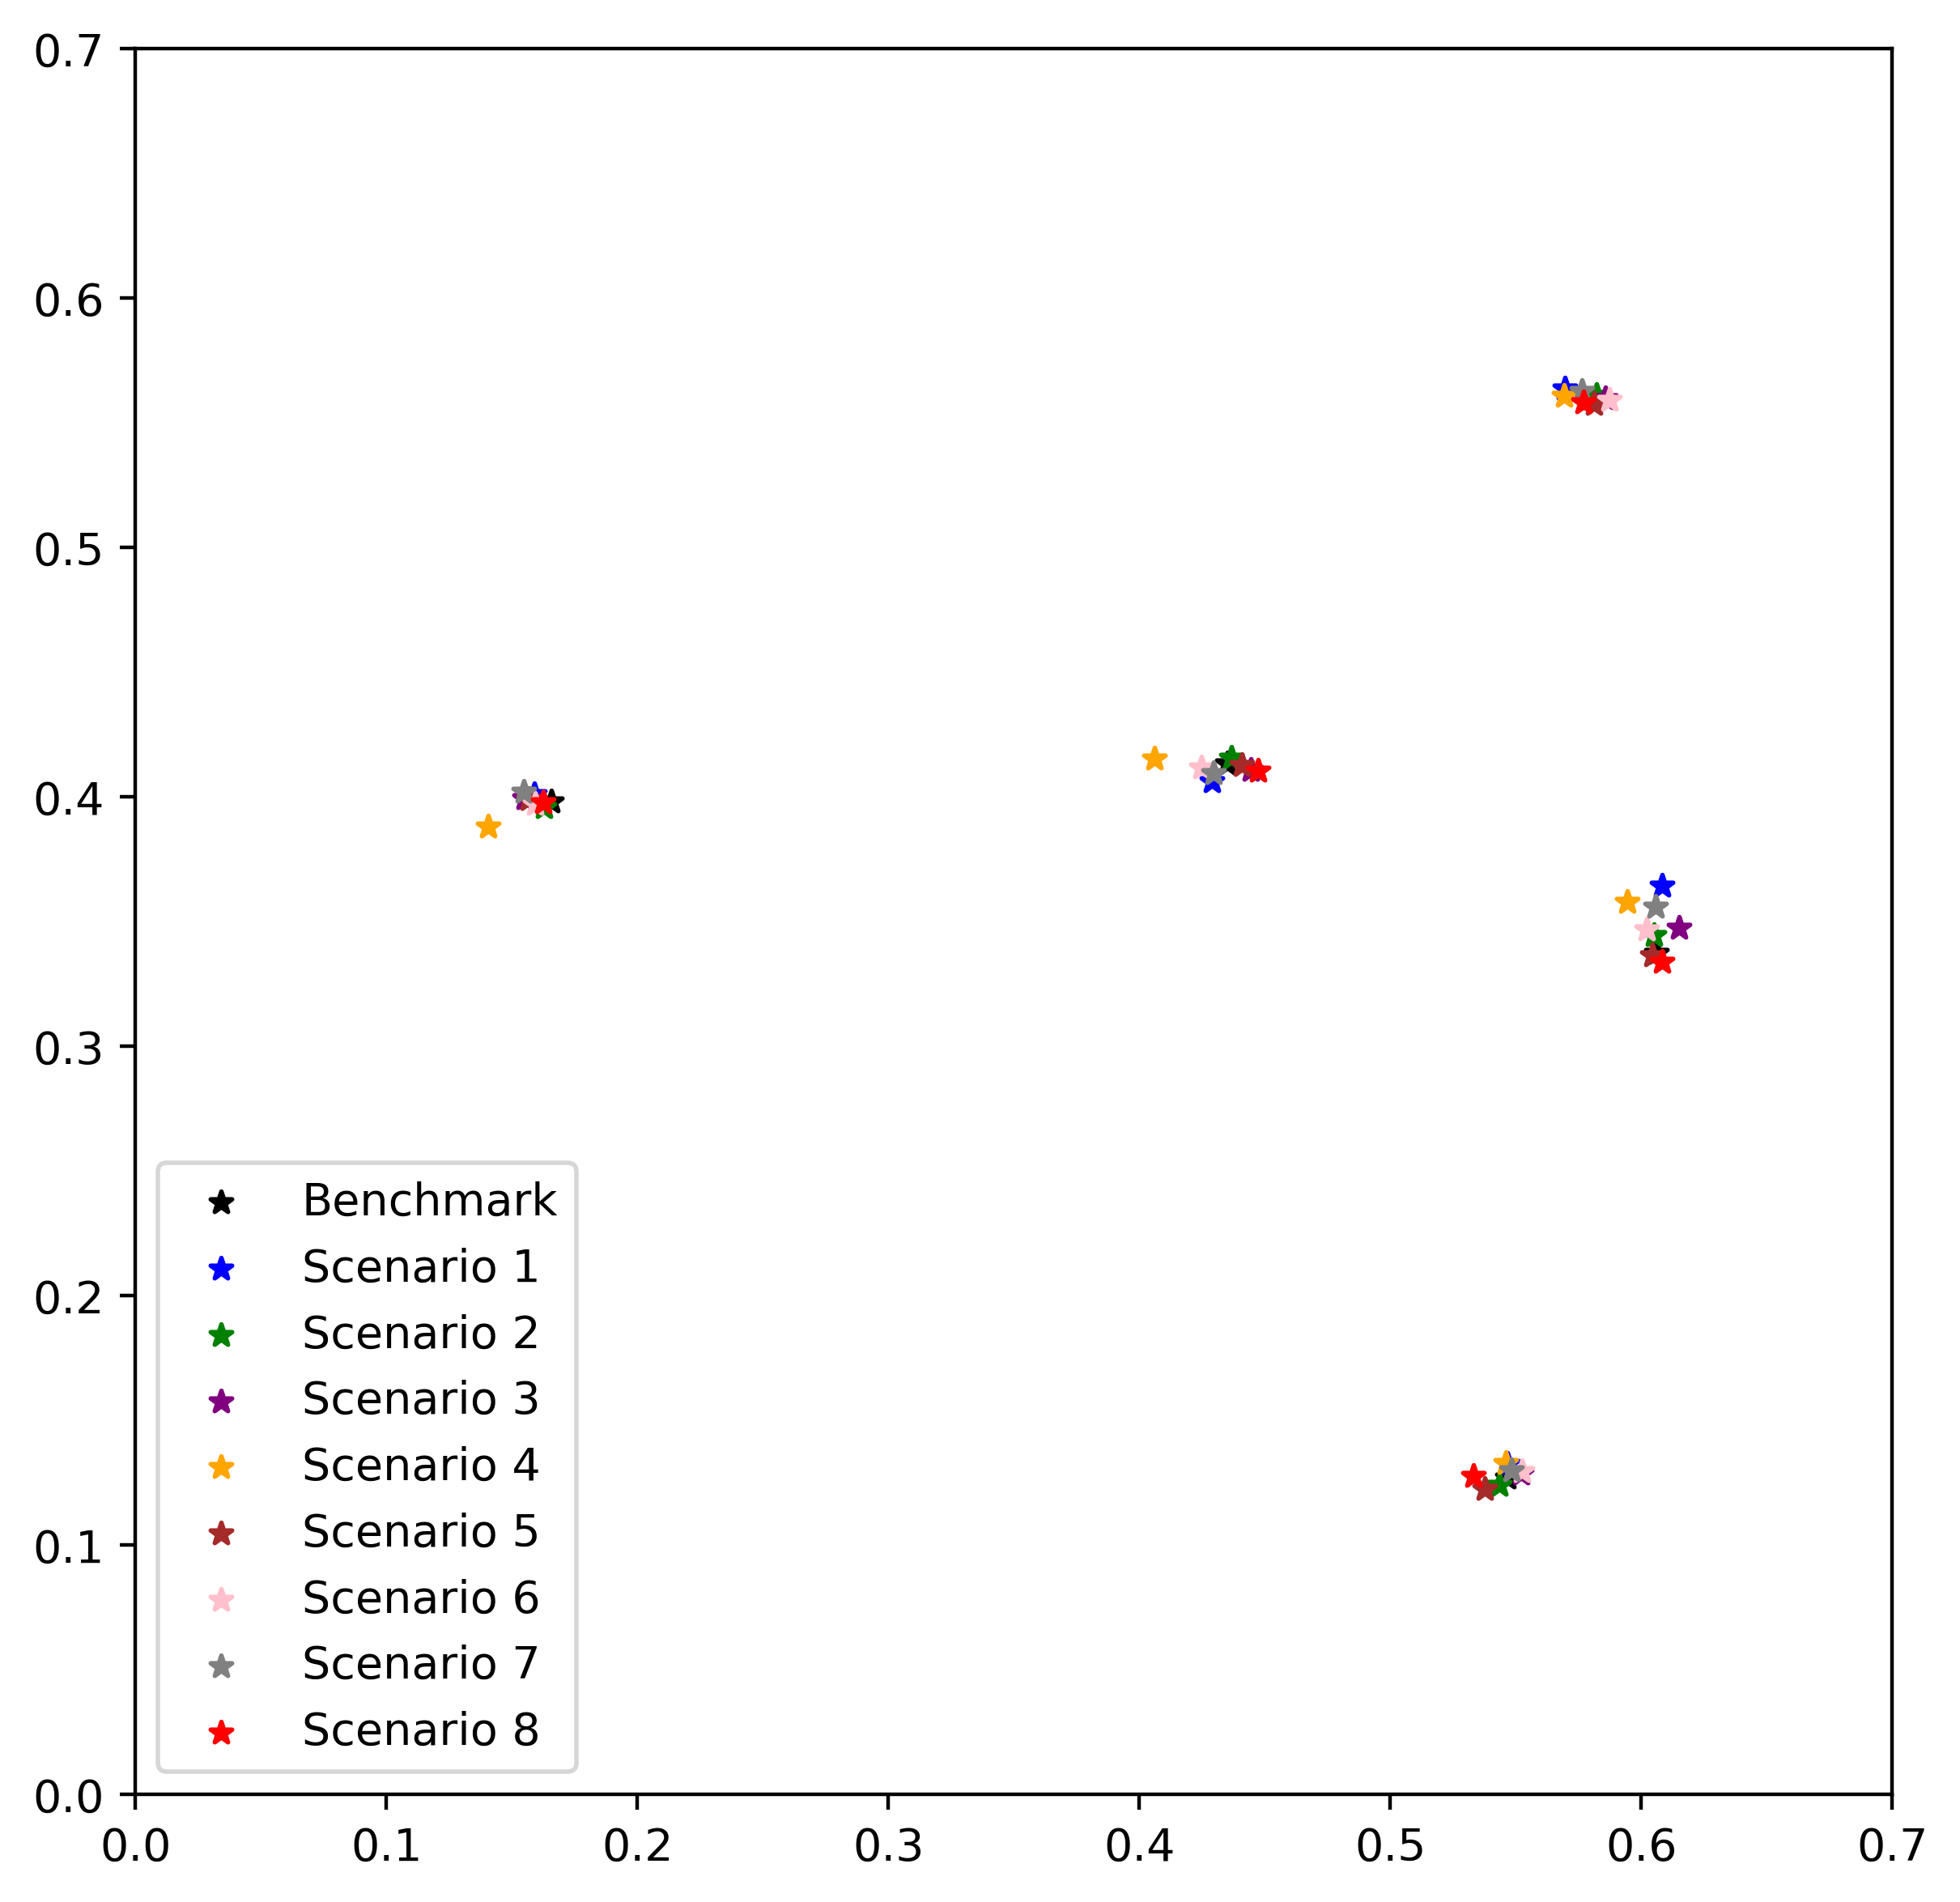

In [11]:
df = pd.read_csv('relative_coordinates.csv')
column1 = df['Rotated_Longitude_miles'].values
column2 = df['Rotated_Latitude_miles'].values
data = np.column_stack((column1, column2))
# Perform KDE
kde = gaussian_kde(data.T)

# Define the grid
x_grid = np.linspace(0, 0.7, 100)
y_grid = np.linspace(0, 0.7, 100)
x, y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([x.ravel(), y.ravel()])

# Evaluate KDE on the grid
# pdf = kde(grid_coords).reshape(100, 100)

# # Plot the KDE
# plt.rcParams['figure.dpi'] = 400
# plt.imshow(pdf, origin='lower', extent=(0, 0.7, 0, 0.7), aspect='auto', cmap='viridis')
# plt.colorbar(label='Density')

plt.figure(figsize=(7, 7))
plt.xlim(0, 0.7)
plt.ylim(0, 0.7)

# coor = [ 11, 2,16, 4,3, 6,11, 9, 17, 9,15, 12,5, 14,12, 16,17, 16]

# for i in range(int(len(coor)/2)):
#     x,y = coordinate(coor[i*2], coor[i*2+1],20)
#     plt.scatter(x,y, color='b', s = 10 )

temp =[0.16569062, 0.39814528 ,0.43492666 ,0.4134408 , 0.5465748,  0.12693656,
 0.5789898  ,0.55944317, 0.60589216 ,0.33748879]


circle_num = 25




### Benchmark
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='black', s = circle_num,marker='*',label="Benchmark")





### Scenario 1

temp = [0.15905415, 0.40086195, 0.42890408, 0.40629282 ,0.54675819, 0.13239479,
 0.56941193, 0.56365361, 0.60833308 ,0.36419725]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='blue', s = circle_num,marker='*',label="Scenario 1")


### Scenario 2

temp = [0.16266447 ,0.39588151 ,0.4366749 , 0.41572125, 0.54328418 ,0.12410031,
 0.58218614 ,0.56106527 ,0.60500763 ,0.34460141]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='green', s = circle_num,marker='*',label="Scenario 2")


### Scenario 3

temp = [0.15493483, 0.39953189, 0.44446139, 0.4107029 , 0.552154 ,  0.12848747,
 0.58583465, 0.55978972 ,0.61496921 ,0.34739032]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='purple', s = circle_num,marker='*',label="Scenario 3")


### Scenario 4

temp = [0.14065059, 0.38814831, 0.40615523 ,0.41522258, 0.54612666, 0.13288648,
 0.5692845 , 0.56082834 ,0.59437991, 0.35796779]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='orange', s = circle_num,marker='*',label="Scenario 4")


### Scenario 5

temp = [0.15669814, 0.39895953 ,0.44089011, 0.41273343, 0.5375743 , 0.12245895,
 0.5811525,  0.55749967, 0.60445075, 0.33639275]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='brown', s = circle_num,marker='*',label="Scenario 5")


### Scenario 6

temp = [0.15936121, 0.39705942, 0.42483562 ,0.41158665, 0.55259162 ,0.12953796,
 0.58736197 ,0.55906951 ,0.60224812 ,0.34667632]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='pink', s = circle_num,marker='*',label="Scenario 6")


### Scenario 7

temp = [0.15475519, 0.40192488, 0.42965576, 0.40951549, 0.54833309 ,0.12985415,
 0.57620271 ,0.56265253 ,0.60552606, 0.35578267]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='gray', s = circle_num,marker='*',label="Scenario 7")

### Scenario 8

temp =  [0.16233567, 0.39772702, 0.44740356 ,0.41047071, 0.53316169, 0.12762505,
 0.57696676, 0.55829288 ,0.60832658 ,0.33381345]
num = int(len(temp)/2)
x = []
y = []
for i in range(int(len(temp)/2)):
	x.append(temp[i*2])
	y.append(temp[i*2+1]) 
	
plt.scatter(x,y, color='red', s = circle_num,marker='*',label="Scenario 8")










# x,y = coordinate(5, 10,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(14, 5,20)
# plt.scatter(x,y, color='b', s = 10 )
# x,y = coordinate(15, 14,20)
# plt.scatter(x,y, color='b', s = 10 )
plt.legend(loc='lower left', fontsize= 10) 
# plt.title('AEDs Locations for 50% adjustment')


plt.savefig("/Users/wuyifan1995/Downloads/Sensitive_50.pdf", format='pdf')
plt.show()






## Appendix

### Appendix Kernel Density Estimation

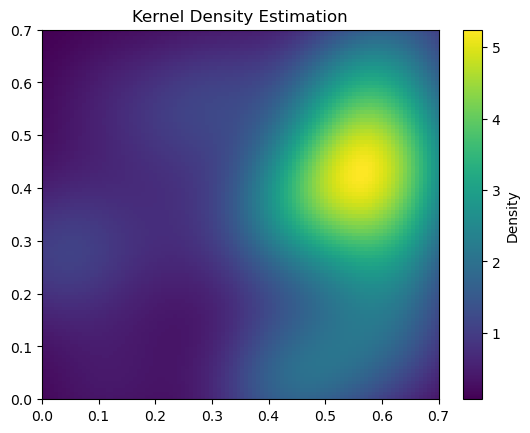

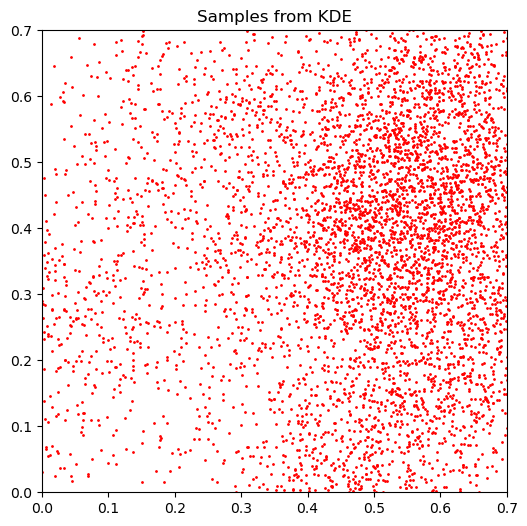

The total sample number is: 5023


In [10]:
df = pd.read_csv('relative_coordinates.csv')
column1 = df['Rotated_Longitude_miles'].values
column2 = df['Rotated_Latitude_miles'].values
data = np.column_stack((column1, column2))
# Perform KDE
kde = gaussian_kde(data.T)

# Define the grid
x_grid = np.linspace(0, 0.7, 100)
y_grid = np.linspace(0, 0.7, 100)
x, y = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([x.ravel(), y.ravel()])

# Evaluate KDE on the grid
pdf = kde(grid_coords).reshape(100, 100)

# Plot the KDE
plt.imshow(pdf, origin='lower', extent=(0, 0.7, 0, 0.7), aspect='auto', cmap='viridis')
plt.colorbar(label='Density')
plt.title('Kernel Density Estimation')
plt.show()

# Sample from the KDE
num_samples = 6300
samples = kde.resample(num_samples).T

# Plot the sampled points
plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=1, color='red')
plt.xlim(0, 0.7)
plt.ylim(0, 0.7)
plt.title('Samples from KDE')
plt.show()

df = pd.DataFrame(samples, columns=['X', 'Y'])

df.head()
df.to_csv("sampled_case_original.csv", index=False)

filtered_df = df[(df.iloc[:, 0] >= 0) & (df.iloc[:, 0] <= 0.7) & 
				 (df.iloc[:, 1] >= 0) & (df.iloc[:, 1] <= 0.7)]

# Save the filtered data back to a CSV file if needed
filtered_df.to_csv('sampled_100,000,000_filtered.csv', index=False)
print("The total sample number is:", len(filtered_df))



In [20]:
print(samples)	
print(len(samples))

[[0.64898703 0.32462984]
 [0.06766917 0.7949997 ]
 [0.17187663 0.46852969]
 ...
 [0.56895951 0.53343463]
 [0.68184056 0.46540979]
 [0.48506057 0.37048609]]
6300
